# PART 1 Clean Each Column

In [2]:
!pip install pyarrow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.1/35.1 MB 9.5 MB/s  0:00:03m0:00:0100:01


In [1]:
# ================================
# 1. Imports and Configuration
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import pyarrow.parquet as pq
import pyarrow as pa

# Enable modern Pandas behavior
pd.options.mode.copy_on_write = True
warnings.filterwarnings("ignore")

# Visual style settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})

PALETTE = sns.color_palette("muted")

# ================================
# 2. Path and Column Definitions
# ================================
DATA_PATH = "data/Project_master_clean.parquet"

needed_cols = [
    "trip_id", "VendorID", "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count", "trip_distance", "RatecodeID", "store_and_fwd_flag",
    "PULocationID", "DOLocationID", "payment_type", "fare_amount", "extra",
    "mta_tax", "tip_amount", "tolls_amount", "improvement_surcharge",
    "total_amount", "congestion_surcharge", "Airport_fee", "cbd_congestion_fee"
]

# ================================
# 3. Safe Loading Logic
# ================================
try:
    # Open the metadata/schema first
    parquet_file = pq.ParquetFile(DATA_PATH)
    all_cols = parquet_file.schema.names

    # Identify existing and missing columns
    existing_cols = [col for col in needed_cols if col in all_cols]
    missing_cols = [col for col in needed_cols if col not in all_cols]

    print(f"Existing columns identified: {len(existing_cols)}")
    if missing_cols:
        print(f"Warning: Missing columns from file: {missing_cols}")

    # FIX: Use pyarrow.Table to read the file directly.
    # This is more robust against 'arrow.py_extension_type' errors 
    # than the standard pd.read_parquet engine.
    table = pq.read_table(DATA_PATH, columns=existing_cols)
    df = table.to_pandas()

    print("-" * 30)
    print(f"✅ Success! Loaded rows: {len(df):,}")
    print(f"Columns in DataFrame: {df.shape[1]}")
    
    # Keep a raw copy for BEFORE-cleaning checks
    df_raw = df.copy()

except Exception as e:
    print("-" * 30)
    print(f"❌ Error loading Parquet: {e}")
    print("\nTroubleshooting Tip: Try 'pip install --upgrade pyarrow pandas'")
    
# ================================
# 4. Preliminary Data Check
# ================================
if 'df' in locals():
    print("\nData Preview:")
    print(df.head())

Existing columns identified: 21
------------------------------
✅ Success! Loaded rows: 11,198,026
Columns in DataFrame: 21

Data Preview:
   trip_id  VendorID tpep_pickup_datetime tpep_dropoff_datetime  \
0        1         1  2025-01-01 00:18:38   2025-01-01 00:26:59   
1        2         1  2025-01-01 00:32:40   2025-01-01 00:35:13   
2        3         1  2025-01-01 00:44:04   2025-01-01 00:46:01   
3        4         2  2025-01-01 00:14:27   2025-01-01 00:20:01   
4        5         2  2025-01-01 00:21:34   2025-01-01 00:25:06   

   passenger_count  trip_distance  RatecodeID store_and_fwd_flag  \
0              1.0           1.60         1.0                  N   
1              1.0           0.50         1.0                  N   
2              1.0           0.60         1.0                  N   
3              3.0           0.52         1.0                  N   
4              3.0           0.66         1.0                  N   

   PULocationID  DOLocationID  ...  fare_amount  e

In [2]:
# ================================
# 3. Standard maps
# ================================

payment_map = {
    0: "Flex Fare",
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided Trip"
}

rate_map = {
    1: "Standard",
    2: "JFK",
    3: "Newark",
    4: "Nassau/Westchester",
    5: "Negotiated",
    6: "Group Ride",
    99: "Null/Unknown"
}

month_map = {
    1: "January",
    2: "February",
    3: "March"
}

dow_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

Datetime pickup/dropoff

In [3]:
# ================================
# 4. Datetime conversion and main cleaning
# ================================

df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"], errors="coerce")
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"], errors="coerce")

# Create duration
df["trip_duration_min"] = (
    df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

print("=== Datetime BEFORE main cleaning ===")
print("Pickup min:", df["tpep_pickup_datetime"].min())
print("Pickup max:", df["tpep_pickup_datetime"].max())
print("Dropoff min:", df["tpep_dropoff_datetime"].min())
print("Dropoff max:", df["tpep_dropoff_datetime"].max())

print("\nDatetime problems BEFORE cleaning:")
print("Missing pickup :", df["tpep_pickup_datetime"].isna().sum())
print("Missing dropoff:", df["tpep_dropoff_datetime"].isna().sum())
print("Pickup outside Jan-Mar 2025:",
      (~((df["tpep_pickup_datetime"] >= "2025-01-01") &
         (df["tpep_pickup_datetime"] < "2025-04-01"))).sum())
print("Negative duration:", (df["trip_duration_min"] < 0).sum())
print("Zero duration    :", (df["trip_duration_min"] == 0).sum())
print("> 180 min        :", (df["trip_duration_min"] > 180).sum())

# Main cleaned analytical layer
df_clean = df[
    (df["tpep_pickup_datetime"] >= "2025-01-01") &
    (df["tpep_pickup_datetime"] < "2025-04-01") &
    (df["tpep_dropoff_datetime"].notna()) &
    (df["trip_duration_min"] > 0)
].copy()

print("\n=== AFTER main cleaning ===")
print("Rows before:", f"{len(df):,}")
print("Rows after :", f"{len(df_clean):,}")
print("Rows removed:", f"{len(df) - len(df_clean):,}")

print("Pickup min:", df_clean["tpep_pickup_datetime"].min())
print("Pickup max:", df_clean["tpep_pickup_datetime"].max())
print("Negative duration:", (df_clean["trip_duration_min"] < 0).sum())
print("Zero duration    :", (df_clean["trip_duration_min"] == 0).sum())
print("> 180 min        :", (df_clean["trip_duration_min"] > 180).sum())

=== Datetime BEFORE main cleaning ===
Pickup min: 2007-12-05 18:45:00
Pickup max: 2025-04-01 00:00:17
Dropoff min: 2007-12-05 19:02:00
Dropoff max: 2025-04-03 14:07:50

Datetime problems BEFORE cleaning:
Missing pickup : 0
Missing dropoff: 0
Pickup outside Jan-Mar 2025: 25
Negative duration: 298
Zero duration    : 29197
> 180 min        : 4252

=== AFTER main cleaning ===
Rows before: 11,198,026
Rows after : 11,168,506
Rows removed: 29,520
Pickup min: 2025-01-01 00:00:00
Pickup max: 2025-03-31 23:59:59
Negative duration: 0
Zero duration    : 0
> 180 min        : 4252


In [4]:
# ================================
# 6. Taxi zone lookup and mapping
# ================================

!wget -O taxi_zone_lookup.csv https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv



zsh:1: command not found: wget


In [4]:
zones = pd.read_csv("taxi_zone_lookup.csv")

print(zones.head())
print(zones.columns)

zone_map = zones.set_index("LocationID")["Zone"].to_dict()
borough_map = zones.set_index("LocationID")["Borough"].to_dict()

df_clean["PUZone"] = df_clean["PULocationID"].map(zone_map)
df_clean["DOZone"] = df_clean["DOLocationID"].map(zone_map)
df_clean["PUBorough"] = df_clean["PULocationID"].map(borough_map)
df_clean["DOBorough"] = df_clean["DOLocationID"].map(borough_map)

print("Missing pickup zone names :", df_clean["PUZone"].isna().sum())
print("Missing dropoff zone names:", df_clean["DOZone"].isna().sum())

   LocationID        Borough                     Zone service_zone
0           1            EWR           Newark Airport          EWR
1           2         Queens              Jamaica Bay    Boro Zone
2           3          Bronx  Allerton/Pelham Gardens    Boro Zone
3           4      Manhattan            Alphabet City  Yellow Zone
4           5  Staten Island            Arden Heights    Boro Zone
Index(['LocationID', 'Borough', 'Zone', 'service_zone'], dtype='object')
Missing pickup zone names : 23106
Missing dropoff zone names: 30467


Rows after datetime cleaning: 11168506
Pickup min: 2025-01-01 00:00:00
Pickup max: 2025-03-31 23:59:59
Dropoff min: 2025-01-01 00:01:38
Dropoff max: 2025-04-03 14:07:50
Negative durations: 0
Zero durations: 0
>180 min durations: 4252


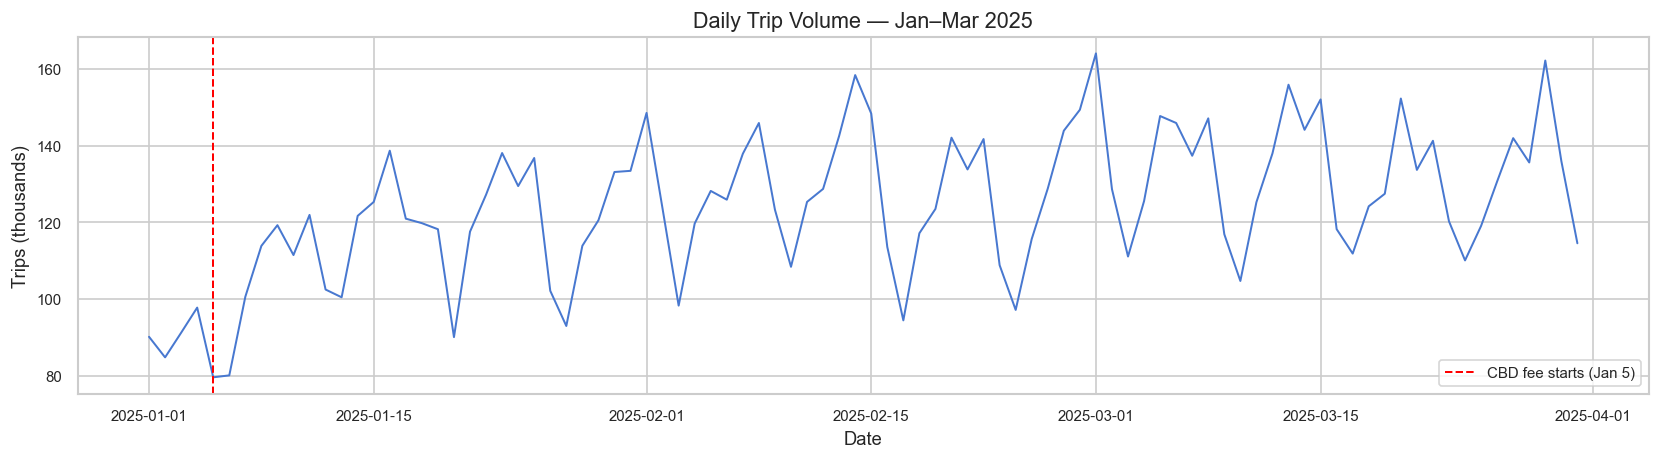

In [6]:
import seaborn as sns

# ── Style ────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})
PALETTE = sns.color_palette('muted')


print("Rows after datetime cleaning:", len(df_clean))
print("Pickup min:", df_clean["tpep_pickup_datetime"].min())
print("Pickup max:", df_clean["tpep_pickup_datetime"].max())
print("Dropoff min:", df_clean["tpep_dropoff_datetime"].min())
print("Dropoff max:", df_clean["tpep_dropoff_datetime"].max())

print("Negative durations:", (df_clean["trip_duration_min"] < 0).sum())
print("Zero durations:", (df_clean["trip_duration_min"] == 0).sum())
print(">180 min durations:", (df_clean["trip_duration_min"] > 180).sum())




df_clean['pickup_date'] = df_clean['tpep_pickup_datetime'].dt.date
df_clean['pickup_time'] = df_clean['tpep_pickup_datetime'].dt.time

df_clean['dropoff_date'] = df_clean['tpep_dropoff_datetime'].dt.date
df_clean['dropoff_time'] = df_clean['tpep_dropoff_datetime'].dt.time

daily = df_clean.groupby('pickup_date').size().reset_index(name='trips')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily['pickup_date'], daily['trips'] / 1000, lw=1.2, color=PALETTE[0])
ax.set_title('Daily Trip Volume — Jan–Mar 2025')
ax.set_ylabel('Trips (thousands)')
ax.set_xlabel('Date')
ax.axvline(pd.Timestamp('2025-01-05'), color='red', ls='--', lw=1.2, label='CBD fee starts (Jan 5)')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
group_cols = ['PULocationID']

df_clean['passenger_count'] = df['passenger_count'].fillna(
    df_clean.groupby(group_cols)['passenger_count'].transform('mean')
)

print("Missing passenger counts after imputation:", df_clean['passenger_count'].isna().sum())

Missing passenger counts after imputation: 0


 passenger_count

In [8]:
# ================================
# Passenger count cleaning
# ================================

print("=== passenger_count BEFORE cleaning ===")
print("Missing :", df_clean["passenger_count"].isna().sum())
print("Zeros   :", (df_clean["passenger_count"] == 0).sum())
print("> 6     :", (df_clean["passenger_count"] > 6).sum())




print("\nValue counts before cleaning:")
print(df_clean["passenger_count"].value_counts(dropna=False).head(15))

df
# Keep only valid passenger counts: 1 to 6
df_passenger = df_clean[
    (df_clean["passenger_count"] >= 1) &
    (df_clean["passenger_count"] <= 6)
].copy()

print("\n=== passenger_count AFTER cleaning ===")
print("Rows after passenger_count cleaning:", f"{len(df_passenger):,}")
print("Missing :", df_passenger["passenger_count"].isna().sum())
print("Zeros   :", (df_passenger["passenger_count"] == 0).sum())
print("> 6     :", (df_passenger["passenger_count"] > 6).sum())

print("\nValue counts after cleaning:")
print(df_passenger["passenger_count"].value_counts().sort_index())

=== passenger_count BEFORE cleaning ===
Missing : 0
Zeros   : 68620
> 6     : 46

Value counts before cleaning:
passenger_count
1.000000    7095698
2.000000    1217014
3.000000     268973
4.000000     169372
1.340238      85888
0.000000      68620
1.318872      63807
1.281695      59191
1.265974      58348
5.000000      53021
1.300764      51926
1.247901      50705
1.251458      49192
1.347900      48369
1.296275      47797
Name: count, dtype: int64

=== passenger_count AFTER cleaning ===
Rows after passenger_count cleaning: 11,099,839
Missing : 0
Zeros   : 0
> 6     : 0

Value counts after cleaning:
passenger_count
1.000000    7095698
1.005302       2032
1.007692        861
1.014628        705
1.015038       1224
             ...   
2.500000         28
3.000000     268973
4.000000     169372
5.000000      53021
6.000000      32928
Name: count, Length: 247, dtype: int64


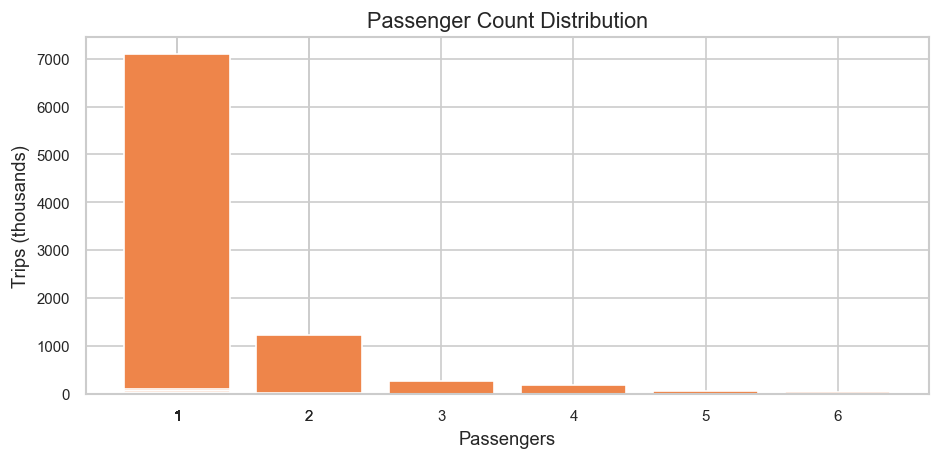

In [9]:
cnt = df_passenger["passenger_count"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))


ax.bar(cnt.index.astype(int), cnt.values / 1000, color=PALETTE[1])

ax.set_title("Passenger Count Distribution")
ax.set_xlabel("Passengers")
ax.set_ylabel("Trips (thousands)")
ax.set_xticks(cnt.index.astype(int))

plt.tight_layout()
plt.show()

trip_distance

In [10]:
# ================================
# Trip distance validation
# ================================

dist_all = df_clean["trip_distance"]

print("=== trip_distance BEFORE cleaning ===")
print(dist_all.describe())

print("\nZero distance  :", (dist_all == 0).sum())
print("Missing        :", dist_all.isna().sum())
print("> 50 miles     :", (dist_all > 50).sum())
print("> 100 miles    :", (dist_all > 100).sum())


# Clean distance values only, not full dataframe
dist_clean = dist_all[
    (dist_all > 0) &
    (dist_all <= 50)
]

print("\n=== trip_distance AFTER cleaning for distance analysis only ===")
print("Rows before:", f"{len(dist_all):,}")
print("Rows after :", f"{len(dist_clean):,}")
print("Rows removed:", f"{len(dist_all) - len(dist_clean):,}")

print(dist_clean.describe())

print("\nZero distance  :", (dist_clean == 0).sum())
print("> 50 miles     :", (dist_clean > 50).sum())
print("> 100 miles    :", (dist_clean > 100).sum())
print('the max dis',df_clean["trip_distance"].max())

=== trip_distance BEFORE cleaning ===
count    1.116851e+07
mean     6.188647e+00
std      5.825884e+02
min      0.000000e+00
25%      1.000000e+00
50%      1.720000e+00
75%      3.250000e+00
max      3.201363e+05
Name: trip_distance, dtype: float64

Zero distance  : 292266
Missing        : 0
> 50 miles     : 1566
> 100 miles    : 541

=== trip_distance AFTER cleaning for distance analysis only ===
Rows before: 11,168,506
Rows after : 10,874,674
Rows removed: 293,832
count    1.087467e+07
mean     3.217931e+00
std      4.044581e+00
min      1.000000e-02
25%      1.050000e+00
50%      1.780000e+00
75%      3.310000e+00
max      5.000000e+01
Name: trip_distance, dtype: float64

Zero distance  : 0
> 50 miles     : 0
> 100 miles    : 0
the max dis 320136.29


In [11]:
df_clean['total_amount'].mean()

np.float64(25.669859448524257)

In [12]:
df_clean.loc[df_clean["trip_distance"] > 100].sort_values(by='trip_distance', ascending=False).head(10)

,trip_id,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,cbd_congestion_fee,trip_duration_min,PUZone,DOZone,PUBorough,DOBorough,pickup_date,pickup_time,dropoff_date,dropoff_time
11044454,11044455,2,2025-03-27 20:52:00,2025-03-27 20:59:00,1.281695,320136.29,NaN,None,161,163,...,0.75,7.0,Midtown Center,Midtown North,Manhattan,Manhattan,2025-03-27,20:52:00,2025-03-27,20:59:00
11029221,11029222,2,2025-03-27 06:32:00,2025-03-27 06:42:00,1.282768,281085.57,NaN,None,215,130,...,0.00,10.0,South Jamaica,Jamaica,Queens,Queens,2025-03-27,06:32:00,2025-03-27,06:42:00
10911115,10911116,2,2025-03-22 05:11:00,2025-03-22 05:31:00,1.282768,280125.56,NaN,None,215,258,...,0.00,20.0,South Jamaica,Woodhaven,Queens,Queens,2025-03-22,05:11:00,2025-03-22,05:31:00
3275762,3275763,2,2025-01-22 21:04:00,2025-01-22 21:13:00,1.281695,276423.57,NaN,None,161,170,...,0.75,9.0,Midtown Center,Murray Hill,Manhattan,Manhattan,2025-01-22,21:04:00,2025-01-22,21:13:00
3188501,3188502,2,2025-01-19 14:51:00,2025-01-19 14:58:00,1.238383,276099.95,NaN,None,224,233,...,0.75,7.0,Stuy Town/Peter Cooper Village,UN/Turtle Bay South,Manhattan,Manhattan,2025-01-19,14:51:00,2025-01-19,14:58:00
10954594,10954595,2,2025-03-23 14:11:00,2025-03-23 14:27:00,1.251458,254846.53,NaN,None,170,158,...,0.75,16.0,Murray Hill,Meatpacking/West Village West,Manhattan,Manhattan,2025-03-23,14:11:00,2025-03-23,14:27:00
10343306,10343307,2,2025-03-02 10:01:00,2025-03-02 10:10:00,1.235519,253020.38,NaN,None,237,236,...,0.00,9.0,Upper East Side South,Upper East Side North,Manhattan,Manhattan,2025-03-02,10:01:00,2025-03-02,10:10:00
6372012,6372013,2,2025-02-06 05:31:00,2025-02-06 05:49:00,1.214682,228782.51,NaN,None,262,68,...,0.75,18.0,Yorkville East,East Chelsea,Manhattan,Manhattan,2025-02-06,05:31:00,2025-02-06,05:49:00
6747356,6747357,2,2025-02-17 05:32:00,2025-02-17 05:53:00,1.194801,222201.03,NaN,None,25,141,...,0.00,21.0,Boerum Hill,Lenox Hill West,Brooklyn,Manhattan,2025-02-17,05:32:00,2025-02-17,05:53:00
3240337,3240338,2,2025-01-21 09:19:00,2025-01-21 09:45:00,1.173701,222167.49,NaN,None,52,144,...,0.75,26.0,Cobble Hill,Little Italy/NoLiTa,Brooklyn,Manhattan,2025-01-21,09:19:00,2025-01-21,09:45:00


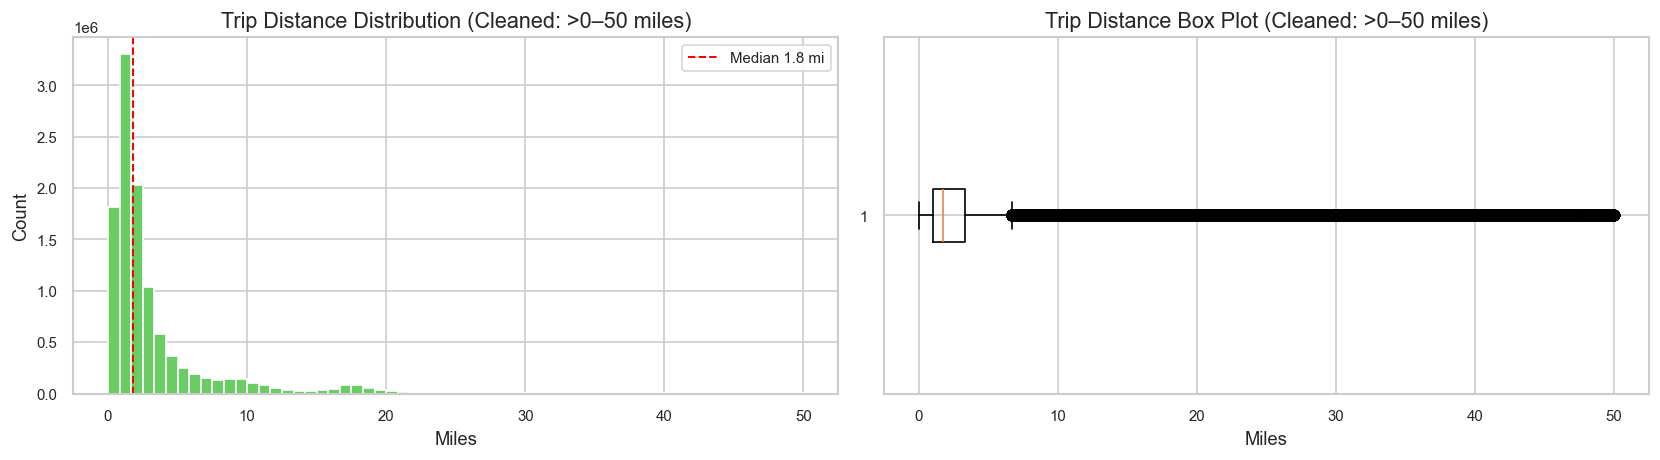

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(dist_clean, bins=60, color=PALETTE[2])
axes[0].axvline(
    dist_clean.median(),
    color="red",
    ls="--",
    lw=1.2,
    label=f"Median {dist_clean.median():.1f} mi"
)
axes[0].set_title("Trip Distance Distribution (Cleaned: >0–50 miles)")
axes[0].set_xlabel("Miles")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].boxplot(dist_clean, vert=False)
axes[1].set_title("Trip Distance Box Plot (Cleaned: >0–50 miles)")
axes[1].set_xlabel("Miles")

plt.tight_layout()
plt.show()

trip_duration_min

=== trip_duration_min BEFORE cleaning ===
count    1.119803e+07
mean     1.550210e+01
std      3.107532e+01
min     -5.147232e+04
25%      7.550000e+00
50%      1.213333e+01
75%      1.895000e+01
max      8.564667e+03

  Negative : 298
  Zero     : 29,197
  > 120 min: 3,811
  Missing  : 0
  Max      : 8564.7 min

=== trip_duration_min AFTER cleaning ===
count    1.116446e+07
mean     1.511806e+01
std      1.176291e+01
min      1.666667e-02
25%      7.583333e+00
50%      1.215000e+01
75%      1.896667e+01
max      2.097833e+02

  Negative : 0
  Zero     : 0
  > 120 min: 2,651
  Missing  : 0

Rows removed from duration analysis: 33,571


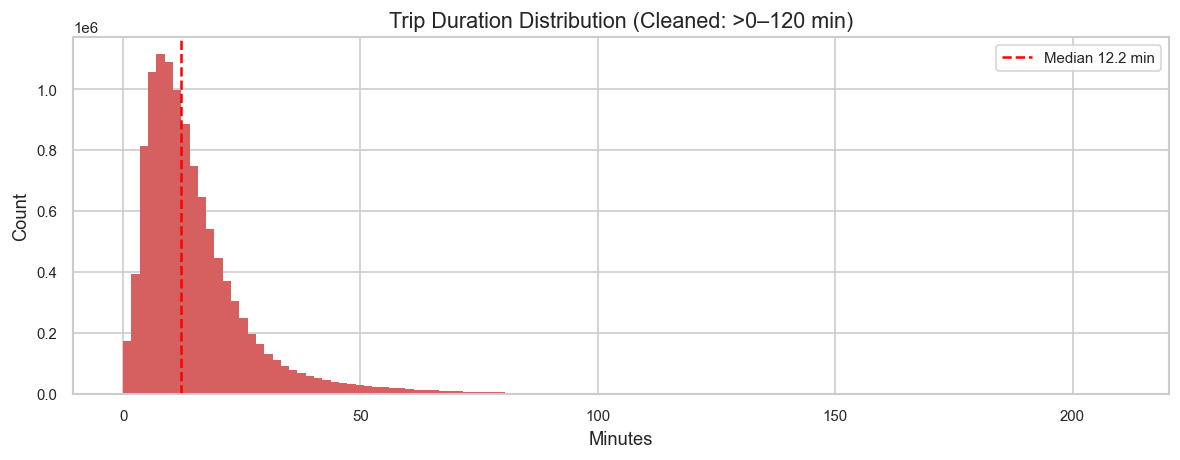

In [14]:
# ================================
# Trip duration: BEFORE cleaning
# ================================

print("=== trip_duration_min BEFORE cleaning ===")
print(df["trip_duration_min"].describe().to_string())

print(f'\n  Negative : {(df["trip_duration_min"] < 0).sum():,}')
print(f'  Zero     : {(df["trip_duration_min"] == 0).sum():,}')
print(f'  > 120 min: {(df["trip_duration_min"] > 300).sum():,}')
print(f'  Missing  : {df["trip_duration_min"].isna().sum():,}')
print(f'  Max      : {df["trip_duration_min"].max():.1f} min')


# ================================
# Trip duration: AFTER cleaning
# ================================

clean_dur = df["trip_duration_min"][
    (df["trip_duration_min"] > 0) &
    (df["trip_duration_min"] <= 210)
]

print("\n=== trip_duration_min AFTER cleaning ===")
print(clean_dur.describe().to_string())

print(f'\n  Negative : {(clean_dur < 0).sum():,}')
print(f'  Zero     : {(clean_dur == 0).sum():,}')
print(f'  > 120 min: {(clean_dur > 120).sum():,}')
print(f'  Missing  : {clean_dur.isna().sum():,}')

print("\nRows removed from duration analysis:", f"{len(df) - len(clean_dur):,}")


# ================================
# Trip duration graph: AFTER cleaning
# ================================

fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(clean_dur, bins=120, color=PALETTE[3], edgecolor="none")

ax.set_title("Trip Duration Distribution (Cleaned: >0–120 min)")
ax.set_xlabel("Minutes")
ax.set_ylabel("Count")

ax.axvline(
    clean_dur.median(),
    color="red",
    ls="--",
    label=f"Median {clean_dur.median():.1f} min"
)

ax.legend()
plt.tight_layout()
plt.show()

RatecodeID

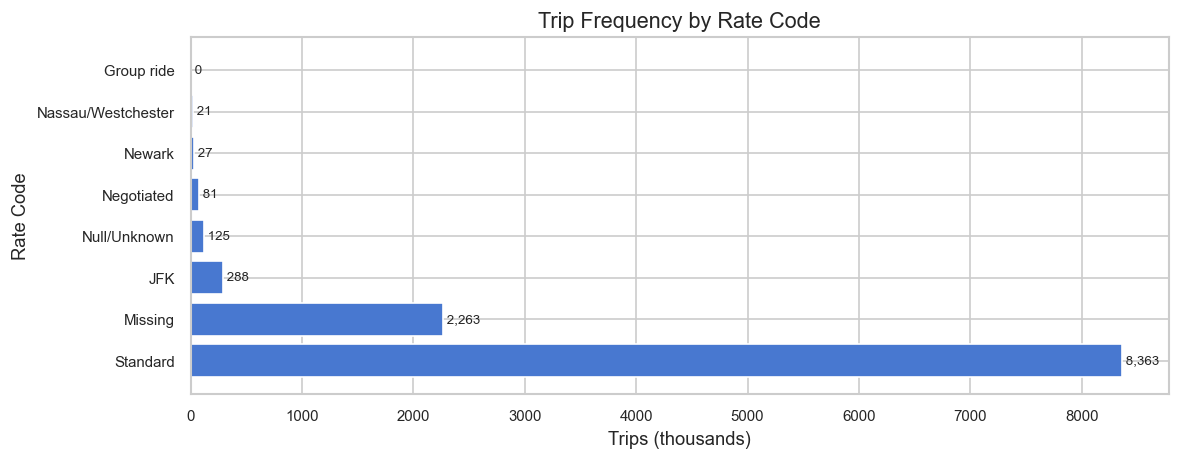

In [15]:
rate_map = {
    1: "Standard",
    2: "JFK",
    3: "Newark",
    4: "Nassau/Westchester",
    5: "Negotiated",
    6: "Group ride",
    99: "Null/Unknown"
}

rate_labels = df_clean["RatecodeID"].map(rate_map).fillna("Missing")

rate_counts = (
    rate_labels
    .value_counts()
    .reset_index()
)

rate_counts.columns = ["Rate Code", "Trips"]

fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.barh(
    rate_counts["Rate Code"],
    rate_counts["Trips"] / 1000,
    color=PALETTE[0]
)

ax.set_title("Trip Frequency by Rate Code")
ax.set_xlabel("Trips (thousands)")
ax.set_ylabel("Rate Code")

for bar in bars:
    width = bar.get_width()
    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f" {width:,.0f}",
        va="center",
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [54]:
df_clean['RatecodeID'].isna().sum()

np.int64(2263178)

store_and_fwd_flag

In [17]:
# ================================
# Clean store_and_fwd_flag
# ================================

print("=== store_and_fwd_flag BEFORE cleaning ===")
print(df_clean["store_and_fwd_flag"].value_counts(dropna=False))

valid_flags = ["Y", "N"]

invalid_flags = (
    df_clean["store_and_fwd_flag"].notna() &
    ~df_clean["store_and_fwd_flag"].isin(valid_flags)
)

print("\nInvalid values before cleaning:", invalid_flags.sum())
print("Missing before cleaning:", df_clean["store_and_fwd_flag"].isna().sum())


# Create cleaned version of the column
df_clean["store_and_fwd_flag_clean"] = df_clean["store_and_fwd_flag"].where(
    df_clean["store_and_fwd_flag"].isin(valid_flags),
    "Missing"
)


print("\n=== store_and_fwd_flag AFTER cleaning ===")
print(df_clean["store_and_fwd_flag_clean"].value_counts(dropna=False))

print("\nInvalid values after cleaning:",
      (~df_clean["store_and_fwd_flag_clean"].isin(["Y", "N", "Missing"])).sum())

=== store_and_fwd_flag BEFORE cleaning ===
store_and_fwd_flag
N       8863207
None    2263178
Y         42121
Name: count, dtype: int64

Invalid values before cleaning: 0
Missing before cleaning: 2263178

=== store_and_fwd_flag AFTER cleaning ===
store_and_fwd_flag_clean
N          8863207
Missing    2263178
Y            42121
Name: count, dtype: int64

Invalid values after cleaning: 0


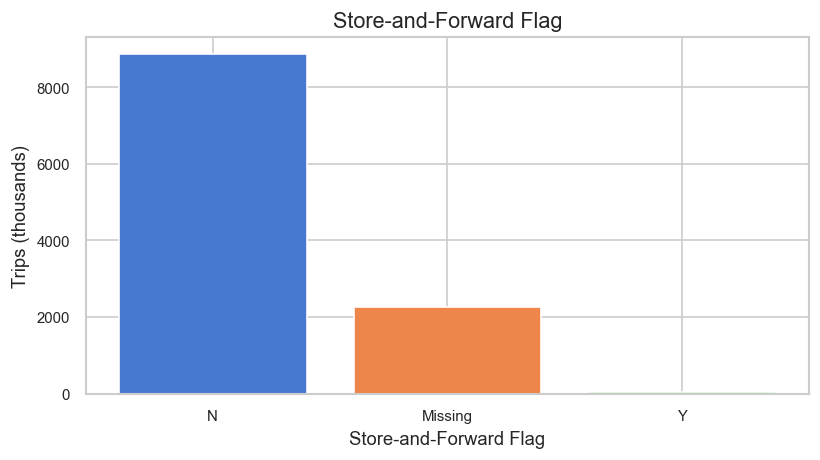

In [18]:
store_counts = (
    df_clean["store_and_fwd_flag_clean"]
    .value_counts()
    .reset_index()
)

store_counts.columns = ["store_and_fwd_flag", "trips"]

fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    store_counts["store_and_fwd_flag"],
    store_counts["trips"] / 1000,
    color=PALETTE[:len(store_counts)]
)

ax.set_title("Store-and-Forward Flag")
ax.set_xlabel("Store-and-Forward Flag")
ax.set_ylabel("Trips (thousands)")

plt.tight_layout()
plt.show()

PULocationID & DOLocationID

In [19]:
# ================================
# Location ID validation
# ================================

print("=== Location IDs ===")

for col in ["PULocationID", "DOLocationID"]:
    print(f"\n  {col}")
    print("    Range    :", df_clean[col].min(), "–", df_clean[col].max())
    print("    Missing  :", df_clean[col].isna().sum())
    print("    Invalid  :", ((df_clean[col] < 1) | (df_clean[col] > 265)).sum(), " (outside 1–265)")
    print("    Top 5 IDs:")
    print(df_clean[col].value_counts().head(5))

=== Location IDs ===

  PULocationID
    Range    : 1 – 265
    Missing  : 0
    Invalid  : 0  (outside 1–265)
    Top 5 IDs:
PULocationID
161    511897
237    489954
236    454765
132    432892
230    376362
Name: count, dtype: int64

  DOLocationID
    Range    : 1 – 265
    Missing  : 0
    Invalid  : 0  (outside 1–265)
    Top 5 IDs:
DOLocationID
236    475049
237    445961
161    398688
230    337117
170    318864
Name: count, dtype: int64


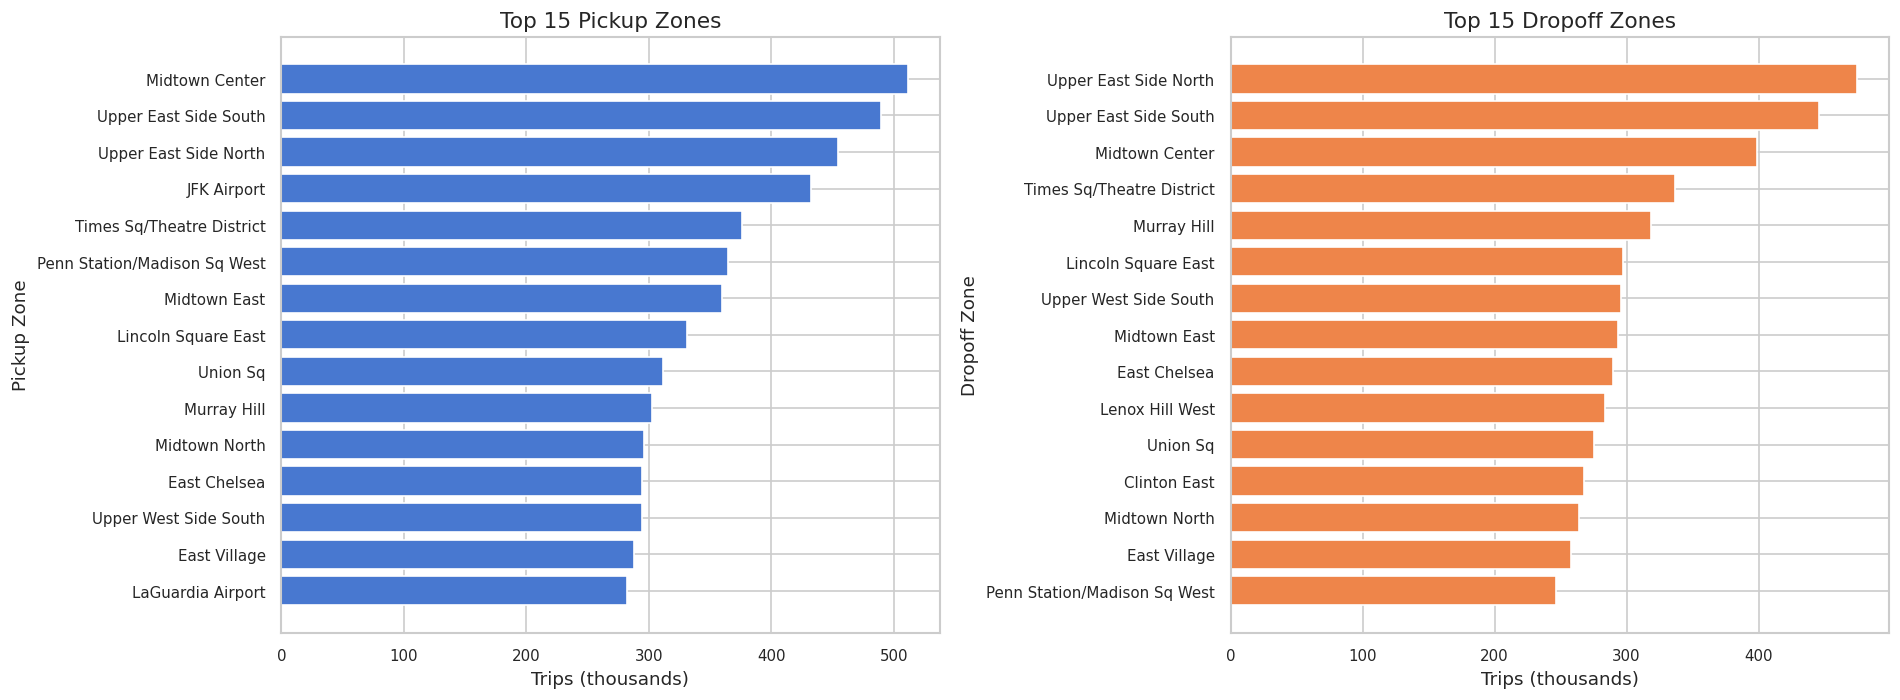

In [ ]:
# ================================
# Top pickup and dropoff zones
# ================================

top_pu = df_clean["PUZone"].value_counts().head(15).sort_values()
top_do = df_clean["DOZone"].value_counts().head(15).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_pu.index, top_pu.values / 1000, color=PALETTE[0])
axes[0].set_title("Top 15 Pickup Zones")
axes[0].set_xlabel("Trips (thousands)")
axes[0].set_ylabel("Pickup Zone")

axes[1].barh(top_do.index, top_do.values / 1000, color=PALETTE[1])
axes[1].set_title("Top 15 Dropoff Zones")
axes[1].set_xlabel("Trips (thousands)")
axes[1].set_ylabel("Dropoff Zone")

plt.tight_layout()
plt.show()

payment_type

=== payment_type ===
Missing : 0
      label   count       pct
Credit Card 7460755 66.801728
  Flex Fare 2263178 20.263928
       Cash 1131379 10.130084
    Dispute  241142  2.159125
  No Charge   72051  0.645127
    Unknown       1  0.000009


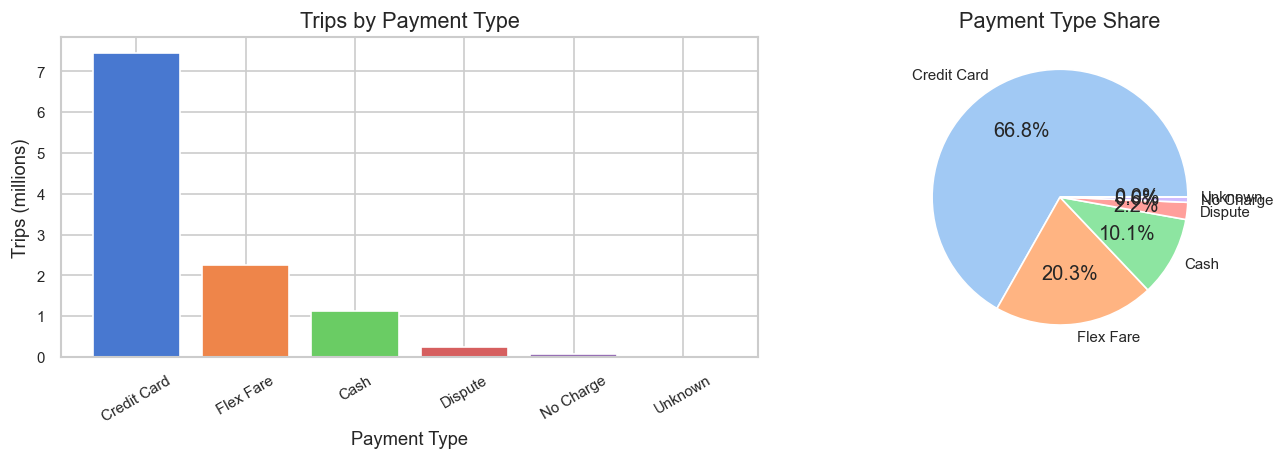

In [20]:
# ================================
# Payment type validation
# ================================



payment_labels = df_clean["payment_type"].map(payment_map)

payment_counts = (
    payment_labels
    .value_counts(dropna=False)
    .reset_index()
)

payment_counts.columns = ["label", "count"]
payment_counts["pct"] = payment_counts["count"] / payment_counts["count"].sum() * 100

print("=== payment_type ===")
print("Missing :", df_clean["payment_type"].isna().sum())
print(payment_counts.to_string(index=False))


# ================================
# Payment type graph
# ================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    payment_counts["label"],
    payment_counts["count"] / 1_000_000,
    color=PALETTE[:len(payment_counts)]
)

axes[0].set_title("Trips by Payment Type")
axes[0].set_xlabel("Payment Type")
axes[0].set_ylabel("Trips (millions)")
axes[0].tick_params(axis="x", rotation=30)

axes[1].pie(
    payment_counts["count"],
    labels=payment_counts["label"],
    autopct="%1.1f%%",
    colors=sns.color_palette("pastel", len(payment_counts))
)

axes[1].set_title("Payment Type Share")

plt.tight_layout()
plt.show()

In [22]:
df_clean[df_clean['payment_type'] == 0]

,trip_id,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,trip_duration_min,PUZone,DOZone,PUBorough,DOBorough,pickup_date,pickup_time,dropoff_date,dropoff_time,store_and_fwd_flag_clean
2935077,2935078,2,2025-01-01 00:39:17,2025-01-01 01:10:42,1.326630,6.75,NaN,None,48,42,...,31.416667,Clinton East,Central Harlem North,Manhattan,Manhattan,2025-01-01,00:39:17,2025-01-01,01:10:42,Missing
2935078,2935079,2,2025-01-01 00:33:40,2025-01-01 01:10:34,1.395758,3.88,NaN,None,4,48,...,36.900000,Alphabet City,Clinton East,Manhattan,Manhattan,2025-01-01,00:33:40,2025-01-01,01:10:34,Missing
2935079,2935080,1,2025-01-01 00:09:32,2025-01-01 00:12:38,1.365338,0.00,NaN,None,158,158,...,3.100000,Meatpacking/West Village West,Meatpacking/West Village West,Manhattan,Manhattan,2025-01-01,00:09:32,2025-01-01,00:12:38,Missing
2935080,2935081,2,2025-01-01 00:21:42,2025-01-01 00:36:29,1.238445,3.55,NaN,None,137,211,...,14.783333,Kips Bay,SoHo,Manhattan,Manhattan,2025-01-01,00:21:42,2025-01-01,00:36:29,Missing
2935081,2935082,2,2025-01-01 00:56:04,2025-01-01 01:06:11,1.206889,1.55,NaN,None,140,233,...,10.116667,Lenox Hill East,UN/Turtle Bay South,Manhattan,Manhattan,2025-01-01,00:56:04,2025-01-01,01:06:11,Missing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11198021,11198022,2,2025-03-31 23:10:10,2025-03-31 23:42:49,1.027266,10.04,NaN,None,177,205,...,32.650000,Ocean Hill,Saint Albans,Brooklyn,Queens,2025-03-31,23:10:10,2025-03-31,23:42:49,Missing
11198022,11198023,2,2025-03-31 23:14:47,2025-03-31 23:32:05,1.272196,3.01,NaN,None,186,140,...,17.300000,Penn Station/Madison Sq West,Lenox Hill East,Manhattan,Manhattan,2025-03-31,23:14:47,2025-03-31,23:32:05,Missing
11198023,11198024,2,2025-03-31 23:18:16,2025-03-31 23:40:15,1.326630,7.44,NaN,None,48,243,...,21.983333,Clinton East,Washington Heights North,Manhattan,Manhattan,2025-03-31,23:18:16,2025-03-31,23:40:15,Missing
11198024,11198025,2,2025-03-31 23:30:16,2025-03-31 23:52:23,1.300764,4.99,NaN,None,68,262,...,22.116667,East Chelsea,Yorkville East,Manhattan,Manhattan,2025-03-31,23:30:16,2025-03-31,23:52:23,Missing


fare_amount

=== fare_amount BEFORE cleaning ===
count    1.116851e+07
mean     1.724495e+01
std      2.623364e+02
min     -1.807600e+03
25%      8.600000e+00
50%      1.280000e+01
75%      2.050000e+01
max      8.633721e+05
Name: fare_amount, dtype: float64
Negative: 535468
Zero: 4363
> $500: 145
the max fare 863372.12

=== fare_amount AFTER cleaning ===
count    1.062853e+07
mean     1.853236e+01
std      1.637034e+01
min      1.000000e-02
25%      9.300000e+00
50%      1.350000e+01
75%      2.120000e+01
max      5.000000e+02
Name: fare_amount, dtype: float64
Negative: 0
Zero: 0
> $500: 0


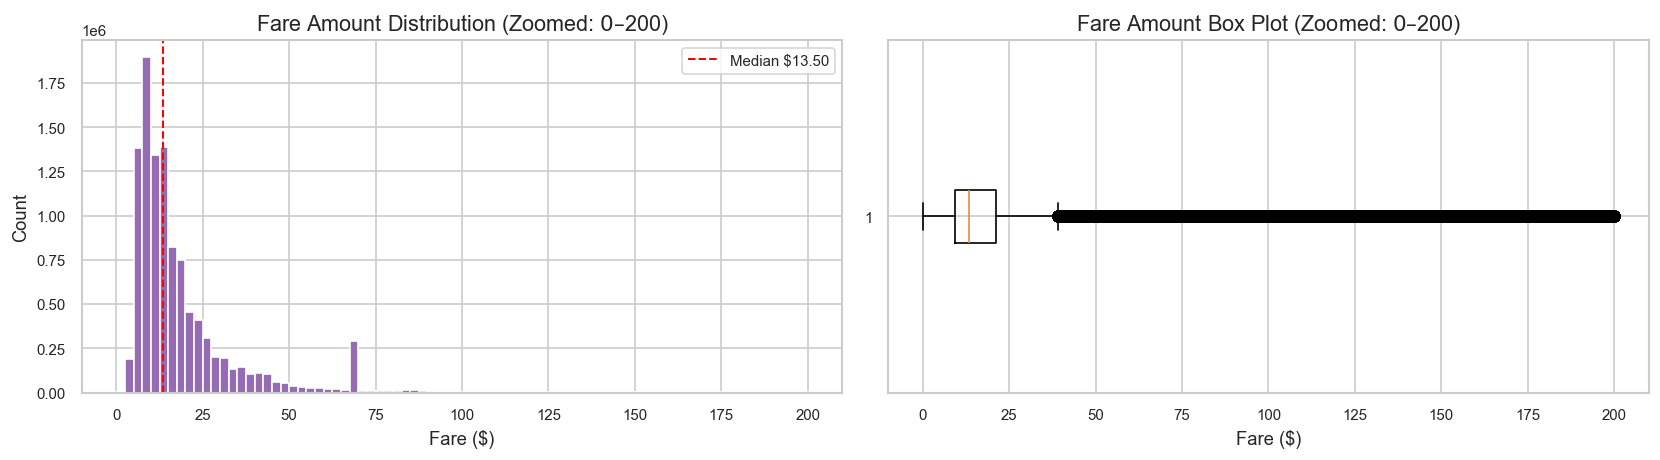

In [24]:
fare_all = df_clean["fare_amount"]

# Cleaning for fare analysis
fare_valid = fare_all[
    (fare_all > 0) &
    (fare_all <= 500)
]

# Zoomed data for graph only
fare_plot = fare_valid[
    fare_valid <= 200
]

print("=== fare_amount BEFORE cleaning ===")
print(fare_all.describe())
print("Negative:", (fare_all < 0).sum())
print("Zero:", (fare_all == 0).sum())
print("> $500:", (fare_all > 500).sum())
print('the max fare',fare_all.max())

print("\n=== fare_amount AFTER cleaning ===")
print(fare_valid.describe())
print("Negative:", (fare_valid < 0).sum())
print("Zero:", (fare_valid == 0).sum())
print("> $500:", (fare_valid > 500).sum())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(fare_plot, bins=80, color=PALETTE[4])
axes[0].axvline(
    fare_plot.median(),
    color="red",
    ls="--",
    lw=1.2,
    label=f"Median ${fare_plot.median():.2f}"
)
axes[0].set_title("Fare Amount Distribution (Zoomed: $0–$200)")
axes[0].set_xlabel("Fare ($)")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].boxplot(fare_plot, vert=False)
axes[1].set_title("Fare Amount Box Plot (Zoomed: $0–$200)")
axes[1].set_xlabel("Fare ($)")

plt.tight_layout()
plt.show()

extra, mta_tax, improvement_surcharge

In [28]:
# ================================
# Surcharge validation and cleaning
# ================================

surcharge_cols = ["extra", "mta_tax", "improvement_surcharge"]

for col in surcharge_cols:
    s = df_clean[col]

    print(f"\n=== {col} BEFORE cleaning ===")
    print(s.describe().round(3))
    print("Missing  :", s.isna().sum())
    print("Negative :", (s < 0).sum())
    print("Zero     :", (s == 0).sum())
    print("> $4.5    :", (s > 4.5).sum())
    print("Max      :", s.max())

# Clean only for surcharge analysis
surcharge_clean = {}

for col in surcharge_cols:
    surcharge_clean[col] = df_clean.loc[
        df_clean[col] >= 0, col
    ]

    print(f"\n=== {col} AFTER cleaning ===")
    print(surcharge_clean[col].describe().round(3))
    print("Negative :", (surcharge_clean[col] < 0).sum())
    print("Rows removed:", f"{len(df_clean) - len(surcharge_clean[col]):,}")


=== extra BEFORE cleaning ===
count    1.116851e+07
mean     1.259000e+00
std      1.853000e+00
min     -9.250000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      2.500000e+00
max      2.255000e+01
Name: extra, dtype: float64
Missing  : 0
Negative : 92906
Zero     : 5911709
> $4.5    : 785214
Max      : 22.55

=== mta_tax BEFORE cleaning ===
count    1.116851e+07
mean     4.790000e-01
std      1.350000e-01
min     -5.000000e-01
25%      5.000000e-01
50%      5.000000e-01
75%      5.000000e-01
max      1.050000e+01
Name: mta_tax, dtype: float64
Missing  : 0
Negative : 175820
Zero     : 117692
> $4.5    : 37
Max      : 10.5

=== improvement_surcharge BEFORE cleaning ===
count    1.116851e+07
mean     9.570000e-01
std      2.720000e-01
min     -1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: improvement_surcharge, dtype: float64
Missing  : 0
Negative : 183042
Zero     : 113339
> $4.5    : 0
Max      : 1.0

=== extra AFTER

In [32]:
df_clean[(df_clean['cbd_congestion_fee'] == 0) & (df_clean['extra'] > 4.5)][['extra', 'fare_amount', 'cbd_congestion_fee']].sort_values(by='extra', ascending=False)

,extra,fare_amount,cbd_congestion_fee
213601,14.25,70.0,0.0
564511,14.25,70.0,0.0
740069,14.25,70.0,0.0
3917861,12.50,70.0,0.0
1219312,12.50,70.0,0.0
...,...,...,...
1528118,5.00,64.0,0.0
1528100,5.00,49.2,0.0
1528016,5.00,40.8,0.0
1528011,5.00,40.8,0.0


In [33]:
df_clean[df_clean['extra'] > 4.50]['cbd_congestion_fee'].value_counts()

cbd_congestion_fee
0.75    515452
0.00    269762
Name: count, dtype: int64

In [ ]:
df_clean[df_clean['improvement_surcharge'] < 0][['improvement_surcharge','VendorID']].value_counts()

improvement_surcharge  VendorID
-1.0                   2           183042
Name: count, dtype: int64

In [40]:
df_clean['VendorID'].value_counts()

VendorID
2    8826446
1    2341194
6        866
Name: count, dtype: int64

In [41]:
df[df['improvement_surcharge'] == 0]['payment_type'].value_counts()

payment_type
1    110904
2      1234
4       725
0       666
3       549
5         1
Name: count, dtype: int64

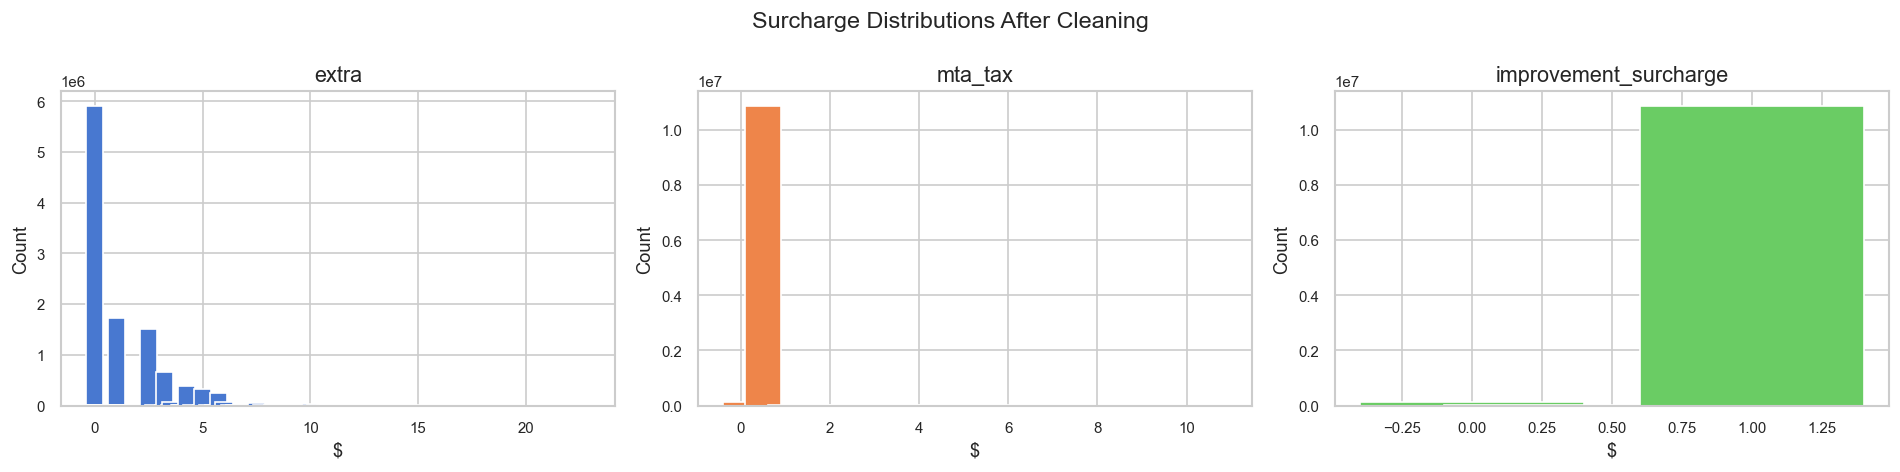

In [34]:
# ================================
# Surcharge distributions after cleaning
# ================================

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, color in zip(axes, surcharge_cols, PALETTE[:3]):
    data = surcharge_clean[col]

    value_counts = data.value_counts().sort_index()

    ax.bar(value_counts.index, value_counts.values, color=color)
    ax.set_title(col)
    ax.set_xlabel("$")
    ax.set_ylabel("Count")

fig.suptitle("Surcharge Distributions After Cleaning", fontsize=14)
plt.tight_layout()
plt.show()

tip_amount


In [42]:
# ================================
# Tip amount validation
# ================================

tip_all = df_clean["tip_amount"]

print("=== tip_amount BEFORE filtering ===")
print(tip_all.describe())

print("\nNegative :", (tip_all < 0).sum())
print("Zero     :", (tip_all == 0).sum())
print("> $50    :", (tip_all > 50).sum())
print("Missing  :", tip_all.isna().sum())


# ================================
# Credit card tips only
# payment_type 1 = Credit Card
# ================================

cc_tips = df_clean.loc[
    (df_clean["payment_type"] == 1) &
    (df_clean["tip_amount"] >= 0),
    "tip_amount"
]

cc_tips_plot = cc_tips[cc_tips <= 30]

cc_tipped = cc_tips[cc_tips > 0]

print("\n=== Credit card tip analysis ===")
print("Credit card trips:", f"{len(cc_tips):,}")
print("Credit card trips with zero tip:", f"{(cc_tips == 0).sum():,}")
print("Credit card trips with tip:", f"{(cc_tips > 0).sum():,}")
print("Median tip among tipped credit card trips:", f"${cc_tipped.median():.2f}")
print("Tips > $30 excluded from graph only:", f"{(cc_tips > 30).sum():,}")

=== tip_amount BEFORE filtering ===
count    1.116851e+07
mean     2.847988e+00
std      3.766116e+00
min     -2.200000e+02
25%      0.000000e+00
50%      2.250000e+00
75%      3.890000e+00
max      4.400000e+02
Name: tip_amount, dtype: float64

Negative : 359
Zero     : 3969431
> $50    : 1742
Missing  : 0

=== Credit card tip analysis ===
Credit card trips: 7,460,722
Credit card trips with zero tip: 455,557
Credit card trips with tip: 7,005,165
Median tip among tipped credit card trips: $3.35
Tips > $30 excluded from graph only: 7,480


In [43]:
df_clean[df_clean["tip_amount"] == 0][["payment_type", "fare_amount", "tip_amount"]].value_counts().head(10)

payment_type  fare_amount  tip_amount
0             -4.75        0.0           254911
2              7.90        0.0            54715
               8.60        0.0            54158
               7.20        0.0            53765
               9.30        0.0            53635
               10.00       0.0            51543
               6.50        0.0            50151
               10.70       0.0            48298
               11.40       0.0            45847
0             -1.50        0.0            44844
Name: count, dtype: int64

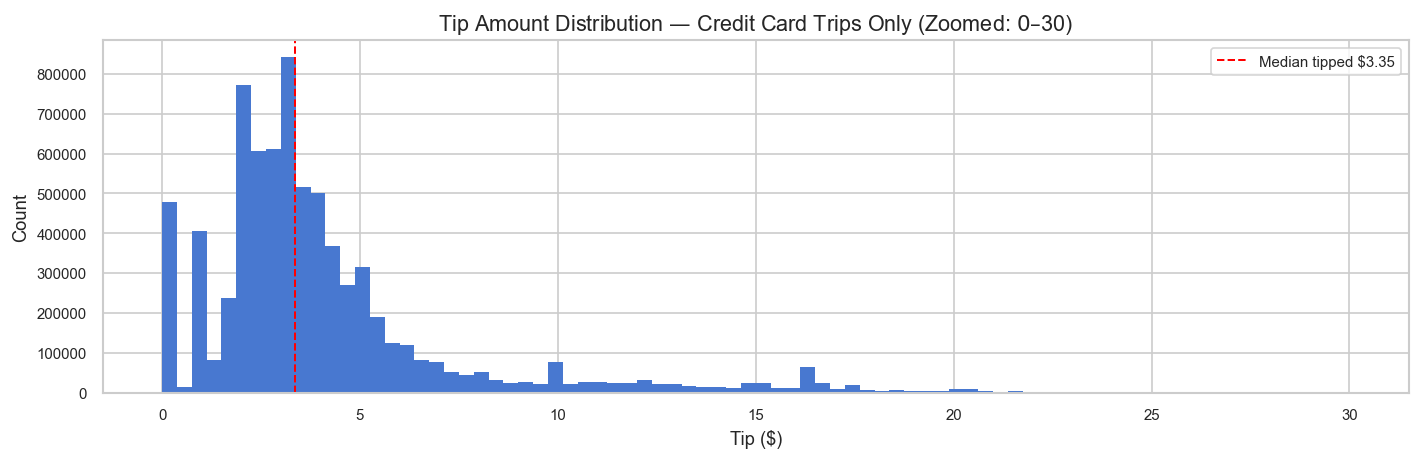

In [44]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.hist(cc_tips_plot, bins=80, color=PALETTE[0], edgecolor="none")

ax.axvline(
    cc_tipped.median(),
    color="red",
    ls="--",
    lw=1.2,
    label=f"Median tipped ${cc_tipped.median():.2f}"
)

ax.set_title("Tip Amount Distribution — Credit Card Trips Only (Zoomed: $0–$30)")
ax.set_xlabel("Tip ($)")
ax.set_ylabel("Count")
ax.legend()

plt.tight_layout()
plt.show()

tolls_amount

In [45]:
# ================================
# Tolls amount validation
# ================================

tolls_all = df_clean["tolls_amount"]

print("=== tolls_amount BEFORE cleaning ===")
print(tolls_all.describe())

print("\nNegative :", (tolls_all < 0).sum())
print("Zero     :", (tolls_all == 0).sum())
print("Non-zero :", (tolls_all > 0).sum())
print("Missing  :", tolls_all.isna().sum())


# ================================
# Clean tolls for toll analysis only
# ================================

tolls_valid = tolls_all[tolls_all >= 0]

# For the graph, show only non-zero tolls up to $30
tolls_plot = tolls_valid[
    (tolls_valid > 0) &
    (tolls_valid <= 30)
]

print("\n=== tolls_amount AFTER cleaning for toll analysis ===")
print(tolls_valid.describe())

print("\nNegative :", (tolls_valid < 0).sum())
print("Zero     :", (tolls_valid == 0).sum())
print("Non-zero :", (tolls_valid > 0).sum())
print("> $30 excluded from graph only:", (tolls_valid > 30).sum())

print("\nRows removed from toll analysis:", f"{len(tolls_all) - len(tolls_valid):,}")

=== tolls_amount BEFORE cleaning ===
count    1.116851e+07
mean     4.449677e-01
std      2.006359e+00
min     -1.421700e+02
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.168700e+02
Name: tolls_amount, dtype: float64

Negative : 14394
Zero     : 10481007
Non-zero : 673105
Missing  : 0

=== tolls_amount AFTER cleaning for toll analysis ===
count    1.115411e+07
mean     4.564629e-01
std      1.973112e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      9.168700e+02
Name: tolls_amount, dtype: float64

Negative : 0
Zero     : 10481007
Non-zero : 673105
> $30 excluded from graph only: 1241

Rows removed from toll analysis: 14,394


In [46]:
df_clean[df_clean["tolls_amount"] == 0][['RatecodeID', 'tolls_amount', 'fare_amount']].value_counts().head(10)

RatecodeID  tolls_amount  fare_amount
1.0         0.0           8.6            439555
                          7.9            438078
                          9.3            432120
                          7.2            418943
                          10.0           417613
                          10.7           394423
                          6.5            374913
                          11.4           372675
                          12.1           347245
                          12.8           319144
Name: count, dtype: int64

In [48]:
df_clean[df_clean["tolls_amount"] == 0]

,trip_id,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,trip_duration_min,PUZone,DOZone,PUBorough,DOBorough,pickup_date,pickup_time,dropoff_date,dropoff_time,store_and_fwd_flag_clean
0,1,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.000000,1.60,1.0,N,229,237,...,8.350000,Sutton Place/Turtle Bay North,Upper East Side South,Manhattan,Manhattan,2025-01-01,00:18:38,2025-01-01,00:26:59,N
1,2,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.000000,0.50,1.0,N,236,237,...,2.550000,Upper East Side North,Upper East Side South,Manhattan,Manhattan,2025-01-01,00:32:40,2025-01-01,00:35:13,N
2,3,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.000000,0.60,1.0,N,141,141,...,1.950000,Lenox Hill West,Lenox Hill West,Manhattan,Manhattan,2025-01-01,00:44:04,2025-01-01,00:46:01,N
3,4,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.000000,0.52,1.0,N,244,244,...,5.566667,Washington Heights South,Washington Heights South,Manhattan,Manhattan,2025-01-01,00:14:27,2025-01-01,00:20:01,N
4,5,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.000000,0.66,1.0,N,244,116,...,3.533333,Washington Heights South,Hamilton Heights,Manhattan,Manhattan,2025-01-01,00:21:34,2025-01-01,00:25:06,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11198021,11198022,2,2025-03-31 23:10:10,2025-03-31 23:42:49,1.027266,10.04,NaN,None,177,205,...,32.650000,Ocean Hill,Saint Albans,Brooklyn,Queens,2025-03-31,23:10:10,2025-03-31,23:42:49,Missing
11198022,11198023,2,2025-03-31 23:14:47,2025-03-31 23:32:05,1.272196,3.01,NaN,None,186,140,...,17.300000,Penn Station/Madison Sq West,Lenox Hill East,Manhattan,Manhattan,2025-03-31,23:14:47,2025-03-31,23:32:05,Missing
11198023,11198024,2,2025-03-31 23:18:16,2025-03-31 23:40:15,1.326630,7.44,NaN,None,48,243,...,21.983333,Clinton East,Washington Heights North,Manhattan,Manhattan,2025-03-31,23:18:16,2025-03-31,23:40:15,Missing
11198024,11198025,2,2025-03-31 23:30:16,2025-03-31 23:52:23,1.300764,4.99,NaN,None,68,262,...,22.116667,East Chelsea,Yorkville East,Manhattan,Manhattan,2025-03-31,23:30:16,2025-03-31,23:52:23,Missing


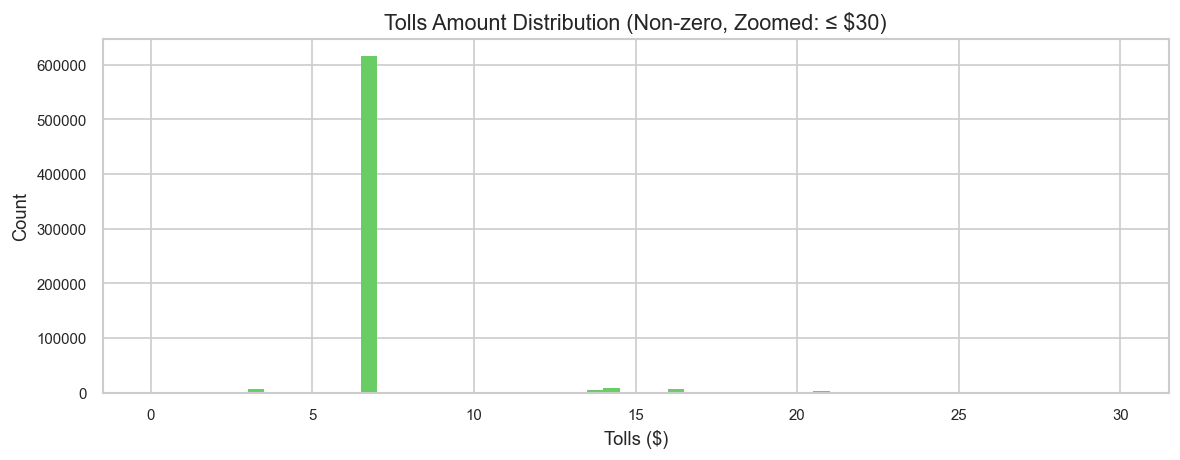

In [49]:
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(tolls_plot, bins=60, color=PALETTE[2], edgecolor="none")

ax.set_title("Tolls Amount Distribution (Non-zero, Zoomed: ≤ $30)")
ax.set_xlabel("Tolls ($)")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

total_amount

=== total_amount BEFORE cleaning ===
count    1.116851e+07
mean     2.566986e+01
std      2.626547e+02
min     -1.832850e+03
25%      1.545000e+01
50%      2.025000e+01
75%      2.843000e+01
max      8.633804e+05
Name: total_amount, dtype: float64
Negative: 186894
Zero: 1492
> $1000: 28

=== total_amount AFTER cleaning ===
count    1.098009e+07
mean     2.647582e+01
std      2.062952e+01
min      1.000000e-02
25%      1.566000e+01
50%      2.055000e+01
75%      2.862000e+01
max      1.000000e+03
Name: total_amount, dtype: float64
Negative: 0
Zero: 0
> $1000: 0


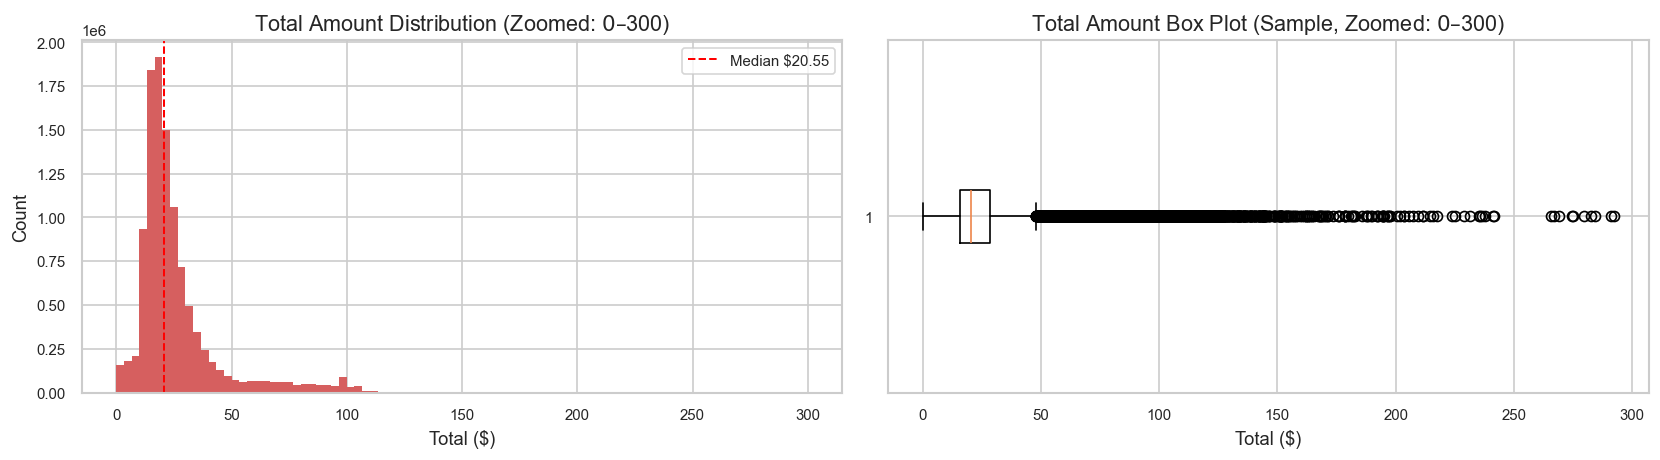

In [50]:
# ===============================
# Total amount validation
# ================================

total_all = df_clean["total_amount"]

# Cleaning for total amount analysis
total_valid = total_all[
    (total_all > 0) &
    (total_all <= 1000)
]

# Zoomed data for graph only
total_plot = total_valid[
    total_valid <= 300
]

print("=== total_amount BEFORE cleaning ===")
print(total_all.describe())
print("Negative:", (total_all < 0).sum())
print("Zero:", (total_all == 0).sum())
print("> $1000:", (total_all > 1000).sum())

print("\n=== total_amount AFTER cleaning ===")
print(total_valid.describe())
print("Negative:", (total_valid < 0).sum())
print("Zero:", (total_valid == 0).sum())
print("> $1000:", (total_valid > 1000).sum())

# ================================
# Total amount graph - memory friendly
# ================================

# Sample for boxplot only to avoid crash
box_sample = total_plot.sample(
    n=min(100_000, len(total_plot)),
    random_state=42
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram
axes[0].hist(total_plot, bins=90, color=PALETTE[3], edgecolor="none")

axes[0].axvline(
    total_plot.median(),
    color="red",
    ls="--",
    lw=1.2,
    label=f"Median ${total_plot.median():.2f}"
)

axes[0].set_title("Total Amount Distribution (Zoomed: $0–$300)")
axes[0].set_xlabel("Total ($)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Boxplot using sample
axes[1].boxplot(box_sample, vert=False, showfliers=True)
axes[1].set_title("Total Amount Box Plot (Sample, Zoomed: $0–$300)")
axes[1].set_xlabel("Total ($)")

plt.tight_layout()
plt.show()

In [54]:
df_clean[df_clean['total_amount'] < 0][['payment_type']].value_counts().head(10)

payment_type
4               115180
2                44415
3                23802
0                 3448
1                   49
Name: count, dtype: int64

congestion_surcharge

=== congestion_surcharge ($) ===
congestion_surcharge
-2.5     148848
 0.0     682685
 1.0          1
 2.5    8073794
 NaN    2263178
Name: count, dtype: int64

Missing : 2263178
Negative: 148848


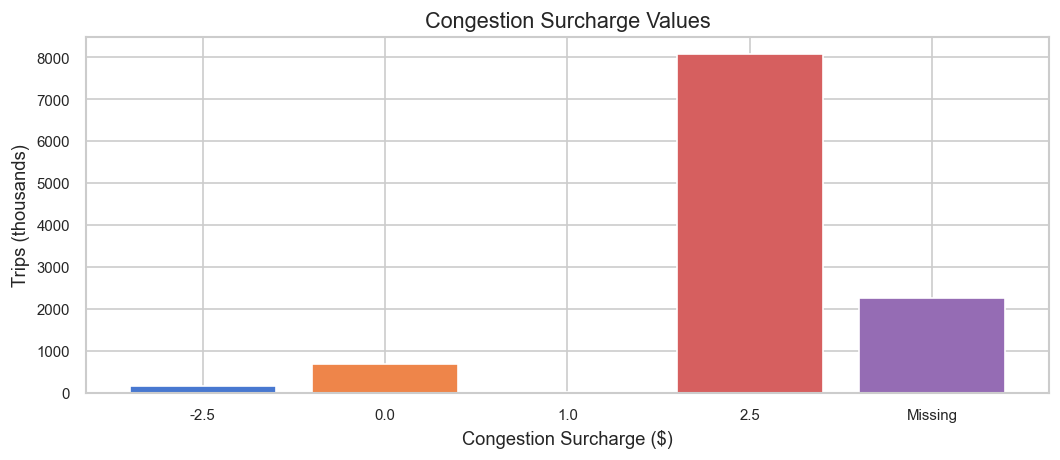

In [55]:
# ================================
# Congestion surcharge validation
# ================================

cong = df_clean["congestion_surcharge"]

print("=== congestion_surcharge ($) ===")
print(cong.value_counts(dropna=False).sort_index())

print("\nMissing :", cong.isna().sum())
print("Negative:", (cong < 0).sum())


# ================================
# Clean labels for graph
# ================================

cong_labels = cong.astype("object").where(cong.notna(), "Missing")

cong_counts = (
    cong_labels
    .value_counts(dropna=False)
    .reset_index()
)

cong_counts.columns = ["amount", "trips"]

# Sort in a readable order
order = [-2.5, 0.0, 1.0, 2.5, "Missing"]
cong_counts["sort_order"] = cong_counts["amount"].apply(
    lambda x: order.index(x) if x in order else 999
)
cong_counts = cong_counts.sort_values("sort_order")


# ================================
# Plot
# ================================

fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(
    cong_counts["amount"].astype(str),
    cong_counts["trips"] / 1000,
    color=PALETTE[:len(cong_counts)]
)

ax.set_title("Congestion Surcharge Values")
ax.set_xlabel("Congestion Surcharge ($)")
ax.set_ylabel("Trips (thousands)")

plt.tight_layout()
plt.show()

 Airport_fee

=== Airport_fee ($) ===
Airport_fee
-1.75      32933
 0.00    8193419
 0.75          1
 1.25          3
 1.75     678971
 5.00          1
 NaN     2263178
Name: count, dtype: int64

Missing  : 2263178
Negative : 32933
Zero     : 8193419
Non-zero : 678976


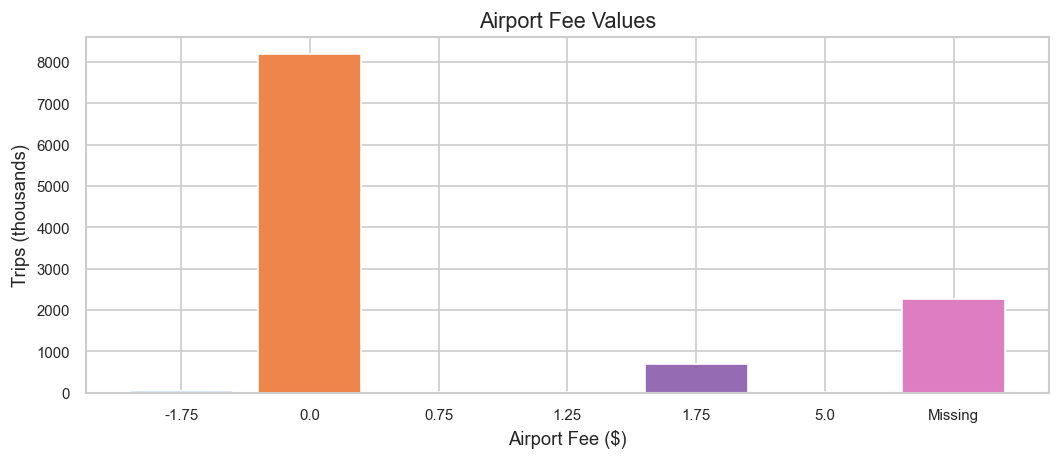

In [56]:
# ================================
# Airport fee validation
# ================================

airport = df_clean["Airport_fee"]

print("=== Airport_fee ($) ===")
print(airport.value_counts(dropna=False).sort_index())

print("\nMissing  :", airport.isna().sum())
print("Negative :", (airport < 0).sum())
print("Zero     :", (airport == 0).sum())
print("Non-zero :", (airport > 0).sum())


# ================================
# Clean labels for graph
# ================================

airport_labels = airport.astype("object").where(airport.notna(), "Missing")

airport_counts = (
    airport_labels
    .value_counts(dropna=False)
    .reset_index()
)

airport_counts.columns = ["amount", "trips"]

# readable sorting
order = [-1.75, 0.0, 0.75, 1.25, 1.75, 5.0, 6.75, "Missing"]

airport_counts["sort_order"] = airport_counts["amount"].apply(
    lambda x: order.index(x) if x in order else 999
)

airport_counts = airport_counts.sort_values("sort_order")


# ================================
# Plot
# ================================

fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(
    airport_counts["amount"].astype(str),
    airport_counts["trips"] / 1000,
    color=PALETTE[:len(airport_counts)]
)

ax.set_title("Airport Fee Values")
ax.set_xlabel("Airport Fee ($)")
ax.set_ylabel("Trips (thousands)")

plt.tight_layout()
plt.show()

cbd_congestion_fee

In [57]:
# ================================
# CBD congestion fee validation
# ================================

cbd = df_clean["cbd_congestion_fee"]

print("=== cbd_congestion_fee BEFORE cleaning ===")
print(cbd.value_counts(dropna=False).sort_index())

print("\nMissing :", cbd.isna().sum())
print("Negative:", (cbd < 0).sum())
print("Rare/unusual values:")
print(cbd[~cbd.isin([0, 0.75, -0.75])].value_counts())


# Pre/post Jan 5 check
before_jan5 = df_clean["tpep_pickup_datetime"] < "2025-01-05"
after_jan5 = df_clean["tpep_pickup_datetime"] >= "2025-01-05"

print("\nTrips before Jan 5 with non-zero CBD fee:",
      ((before_jan5) & (df_clean["cbd_congestion_fee"] != 0)).sum())

print("Trips after Jan 5 with non-zero CBD fee:",
      ((after_jan5) & (df_clean["cbd_congestion_fee"] != 0)).sum())

=== cbd_congestion_fee BEFORE cleaning ===
cbd_congestion_fee
-0.75      90956
 0.00    3239662
 0.25          1
 0.75    7837749
 1.25        129
 1.50          9
Name: count, dtype: int64

Missing : 0
Negative: 90956
Rare/unusual values:
cbd_congestion_fee
1.25    129
1.50      9
0.25      1
Name: count, dtype: int64

Trips before Jan 5 with non-zero CBD fee: 401
Trips after Jan 5 with non-zero CBD fee: 7928443


In [58]:
# Cleaned version for CBD-specific analysis only
# Does NOT change df_clean

df_cbd = df_clean[
    (
        # before Jan 5, CBD fee should be 0
        ((df_clean["tpep_pickup_datetime"] < "2025-01-05") &
         (df_clean["cbd_congestion_fee"] == 0))
        |
        # after Jan 5, allow normal 0 or 0.75 values
        ((df_clean["tpep_pickup_datetime"] >= "2025-01-05") &
         (df_clean["cbd_congestion_fee"].isin([0, 0.75])))
    )
].copy()

print("Rows in df_clean:", f"{len(df_clean):,}")
print("Rows in df_cbd:", f"{len(df_cbd):,}")
print("Rows excluded from CBD-specific analysis:", f"{len(df_clean) - len(df_cbd):,}")

Rows in df_clean: 11,168,506
Rows in df_cbd: 11,077,010
Rows excluded from CBD-specific analysis: 91,496


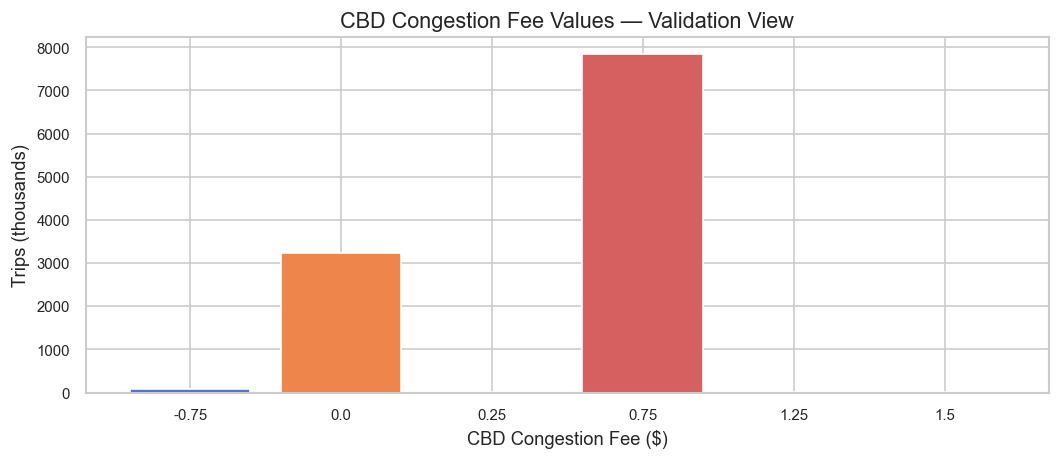

In [59]:
cbd_labels = df_clean["cbd_congestion_fee"].astype("object")

cbd_counts = cbd_labels.value_counts(dropna=False).sort_index()

fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(
    cbd_counts.index.astype(str),
    cbd_counts.values / 1000,
    color=PALETTE[:len(cbd_counts)]
)

ax.set_title("CBD Congestion Fee Values — Validation View")
ax.set_xlabel("CBD Congestion Fee ($)")
ax.set_ylabel("Trips (thousands)")

plt.tight_layout()
plt.show()

source_month

In [60]:
df_clean["pickup_month"] = df_clean["tpep_pickup_datetime"].dt.to_period("M").astype(str)

month_counts = (
    df_clean["pickup_month"]
    .value_counts()
    .sort_index()
)

print("=== pickup_month ===")
print(month_counts)

=== pickup_month ===
pickup_month
2025-01    3473183
2025-02    3572378
2025-03    4122945
Name: count, dtype: int64


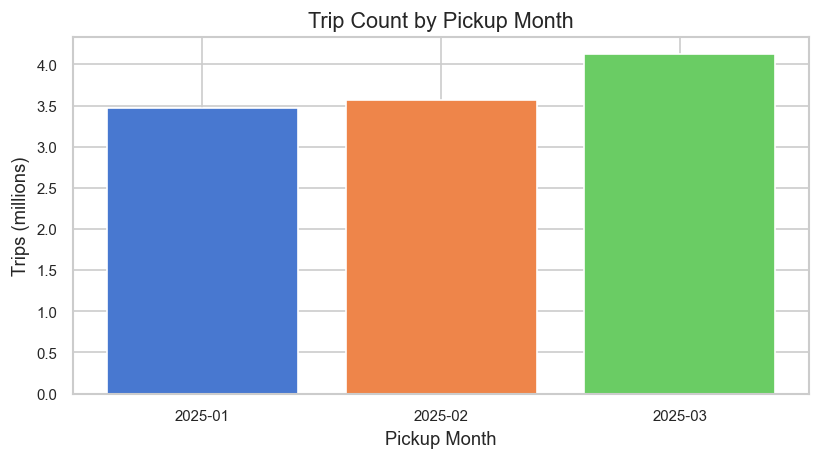

In [61]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.bar(
    month_counts.index,
    month_counts.values / 1_000_000,
    color=PALETTE[:len(month_counts)]
)

ax.set_title("Trip Count by Pickup Month")
ax.set_xlabel("Pickup Month")
ax.set_ylabel("Trips (millions)")

plt.tight_layout()
plt.show()

# PART 2 — Column Relationships (Bivariate & Multivariate EDA) clean

Hour of Day vs Trip Volume

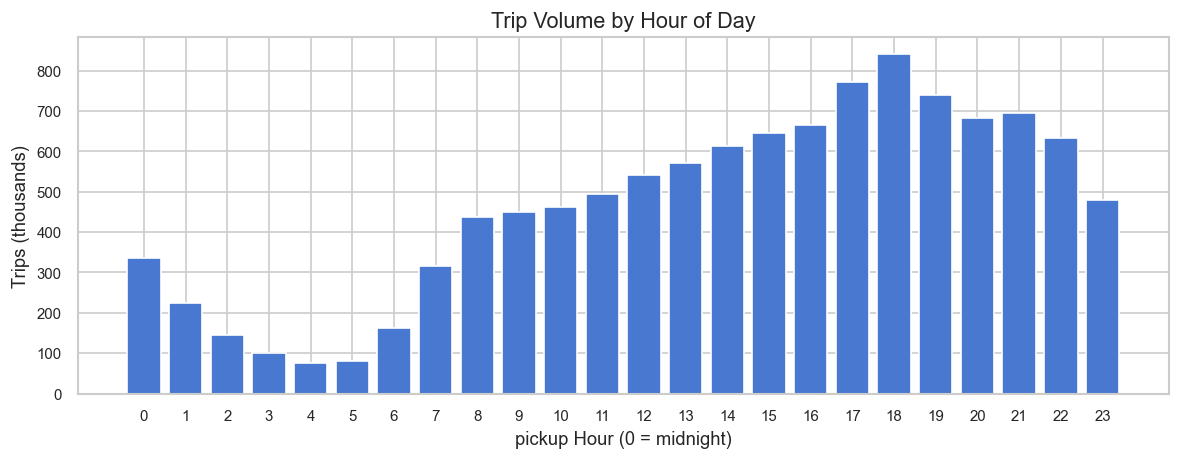

In [66]:
df_clean["pickup_hour"] = df_clean["tpep_pickup_datetime"].dt.hour

hourly = df_clean.groupby('pickup_hour').size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(hourly.index, hourly.values / 1000, color=PALETTE[0])
ax.set_title('Trip Volume by Hour of Day')
ax.set_xlabel('pickup Hour (0 = midnight)')
ax.set_ylabel('Trips (thousands)')
ax.set_xticks(range(24))
plt.tight_layout()
plt.show()

Weekday vs Trip Demand

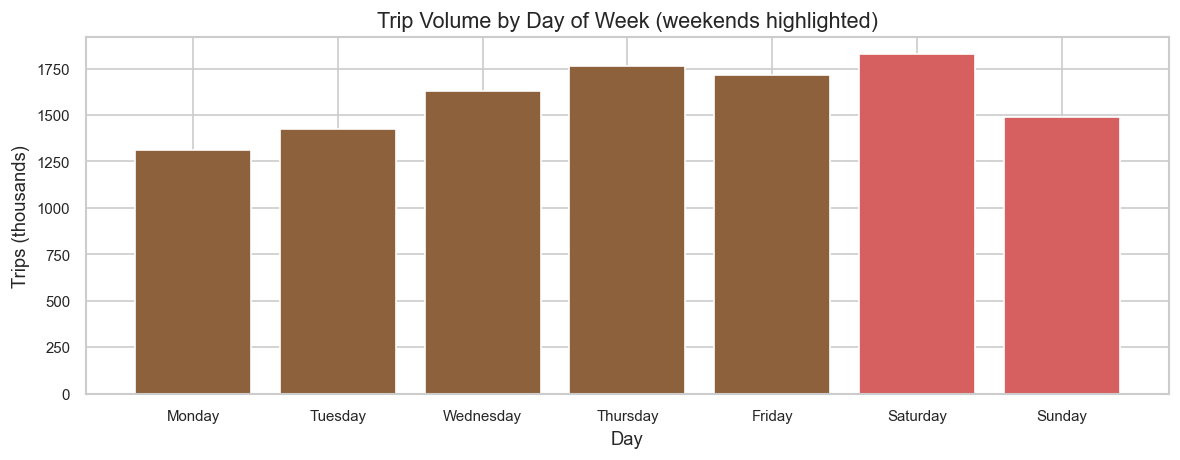

In [68]:
df_clean["pickup_dow"] = df_clean["tpep_pickup_datetime"].dt.day_name()

dow_vol = (
    df_clean.groupby('pickup_dow').size()
    .reindex(dow_order)
    .reset_index(name='trips')
)

fig, ax = plt.subplots(figsize=(10, 4))
colors = [PALETTE[5]] * 5 + [PALETTE[3]] * 2  # highlight weekends
ax.bar(dow_vol['pickup_dow'], dow_vol['trips'] / 1000, color=colors)
ax.set_title('Trip Volume by Day of Week (weekends highlighted)')
ax.set_ylabel('Trips (thousands)')
ax.set_xlabel('Day')
plt.tight_layout()
plt.show()

Hour × Weekday Heatmap

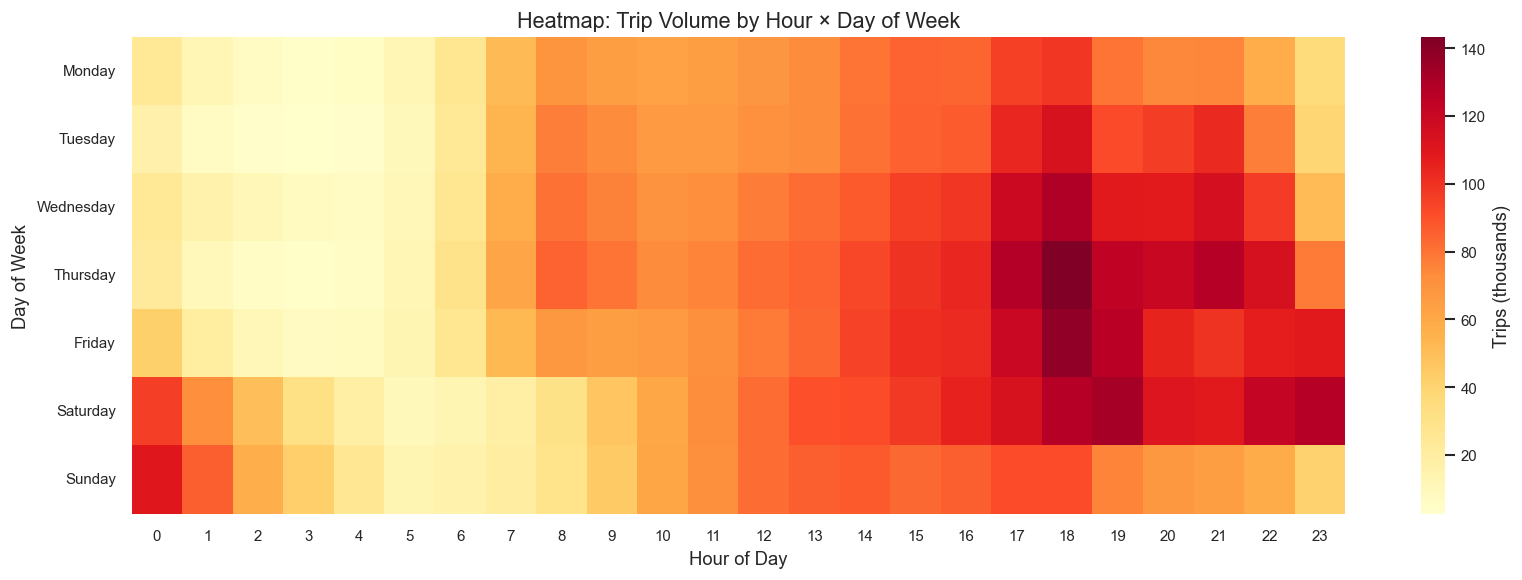

In [70]:
pivot_hw = (
    df_clean.groupby(['pickup_dow', 'pickup_hour'])
    .size()
    .unstack()
    .reindex(dow_order)
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_hw / 1000, ax=ax, cmap='YlOrRd',
            cbar_kws={'label': 'Trips (thousands)'})
ax.set_title('Heatmap: Trip Volume by Hour × Day of Week')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.show()

Payment Type vs Tip or Total Amount

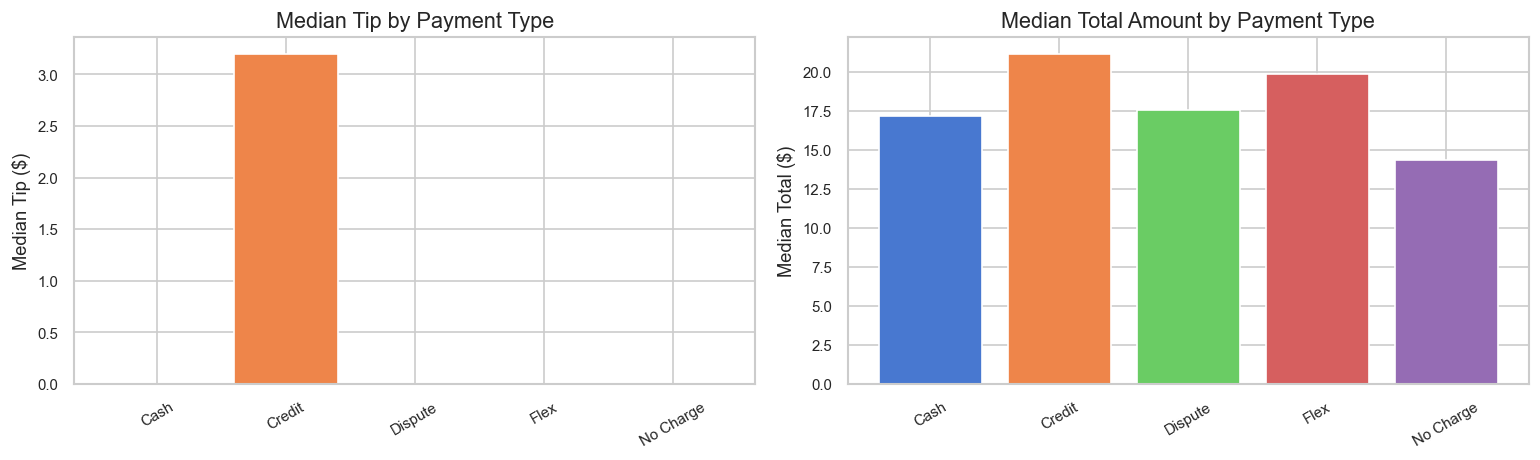

In [71]:
pay_label = {0:'Flex',1:'Credit',2:'Cash',3:'No Charge',4:'Dispute',5:'Unknown',6:'Voided'}

pt_tip = (
    df_clean[(df_clean.total_amount > 0) & (df_clean.total_amount <= 200)]
    .assign(pay_label=lambda x: x['payment_type'].map(pay_label))
    .groupby('pay_label')[['tip_amount','total_amount']]
    .median()
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(pt_tip['pay_label'], pt_tip['tip_amount'], color=PALETTE[:len(pt_tip)])
axes[0].set_title('Median Tip by Payment Type')
axes[0].set_ylabel('Median Tip ($)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(pt_tip['pay_label'], pt_tip['total_amount'], color=PALETTE[:len(pt_tip)])
axes[1].set_title('Median Total Amount by Payment Type')
axes[1].set_ylabel('Median Total ($)')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

Distance vs Total Amount

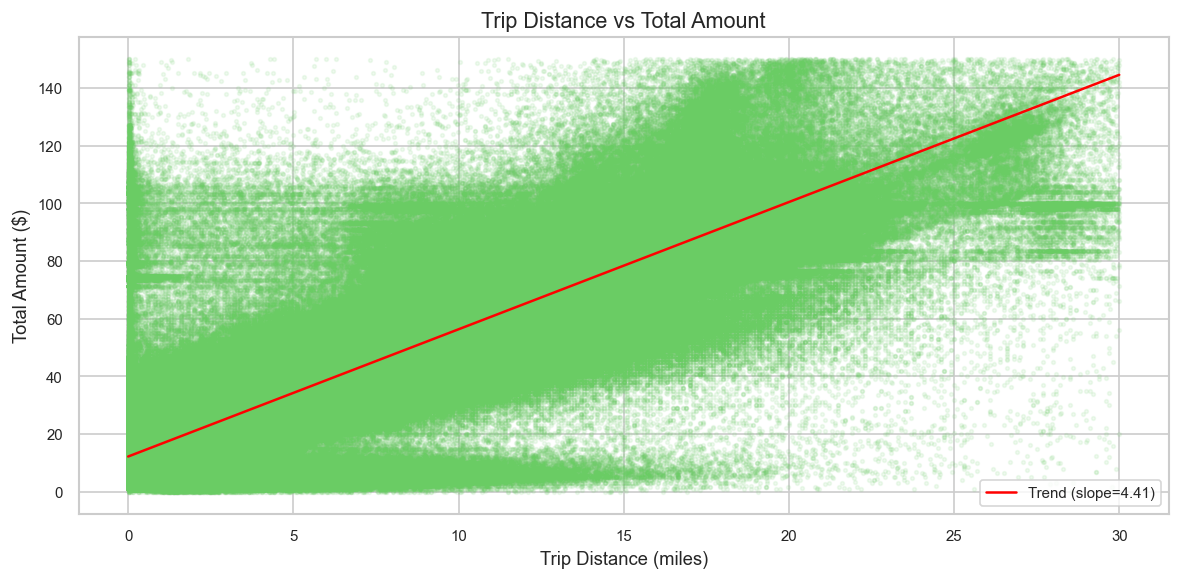

In [ ]:
sample = df_clean[
    (df_clean.trip_distance > 0) & (df_clean.trip_distance <= 30) &
    (df_clean.total_amount > 0) & (df_clean.total_amount <= 150)
].sample(50_000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sample['trip_distance'], sample['total_amount'],
           alpha=0.1, s=5, color=PALETTE[2])
ax.set_title('Trip Distance vs Total Amount (50k sample)')
ax.set_xlabel('Trip Distance (miles)')
ax.set_ylabel('Total Amount ($)')

# Trend line
z = np.polyfit(sample['trip_distance'], sample['total_amount'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 30, 100)
ax.plot(x_line, p(x_line), color='red', lw=1.5, label=f'Trend (slope={z[0]:.2f})')
ax.legend()
plt.tight_layout()
plt.show()

Distance vs Duration

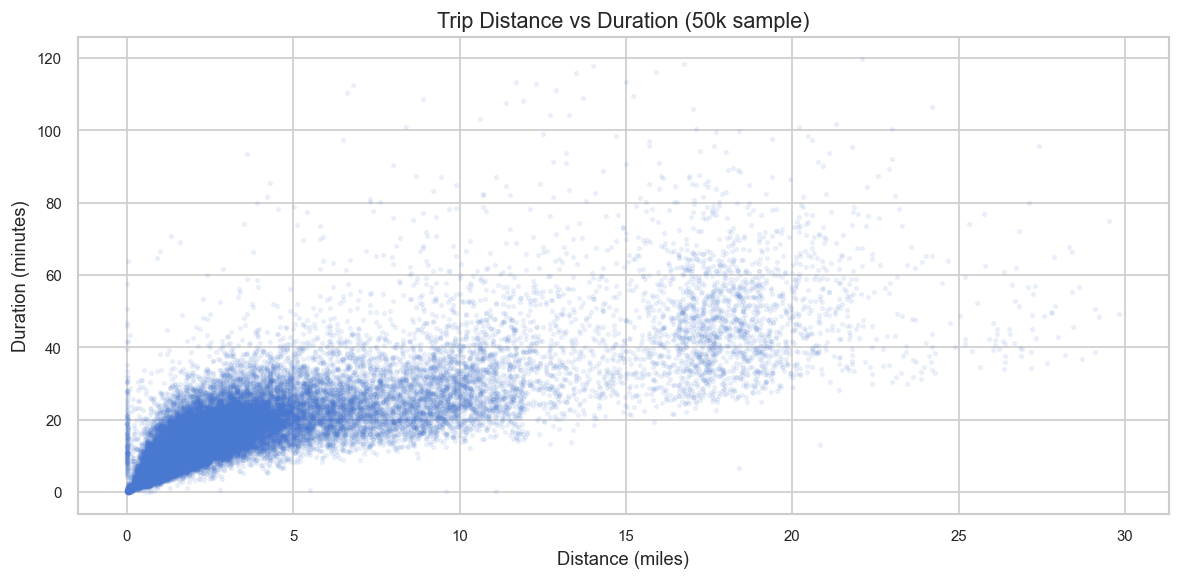

In [77]:
sample2 = df_clean[
    (df_clean.trip_distance > 0) & (df_clean.trip_distance <= 30) &
    (df_clean.trip_duration_min > 0) & (df_clean.trip_duration_min <= 120)
].sample(50_000, random_state=42)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(sample2['trip_distance'], sample2['trip_duration_min'],
           alpha=0.08, s=5, color=PALETTE[0])
ax.set_title('Trip Distance vs Duration (50k sample)')
ax.set_xlabel('Distance (miles)')
ax.set_ylabel('Duration (minutes)')
plt.tight_layout()
plt.show()

Rate Code vs Fare Amount

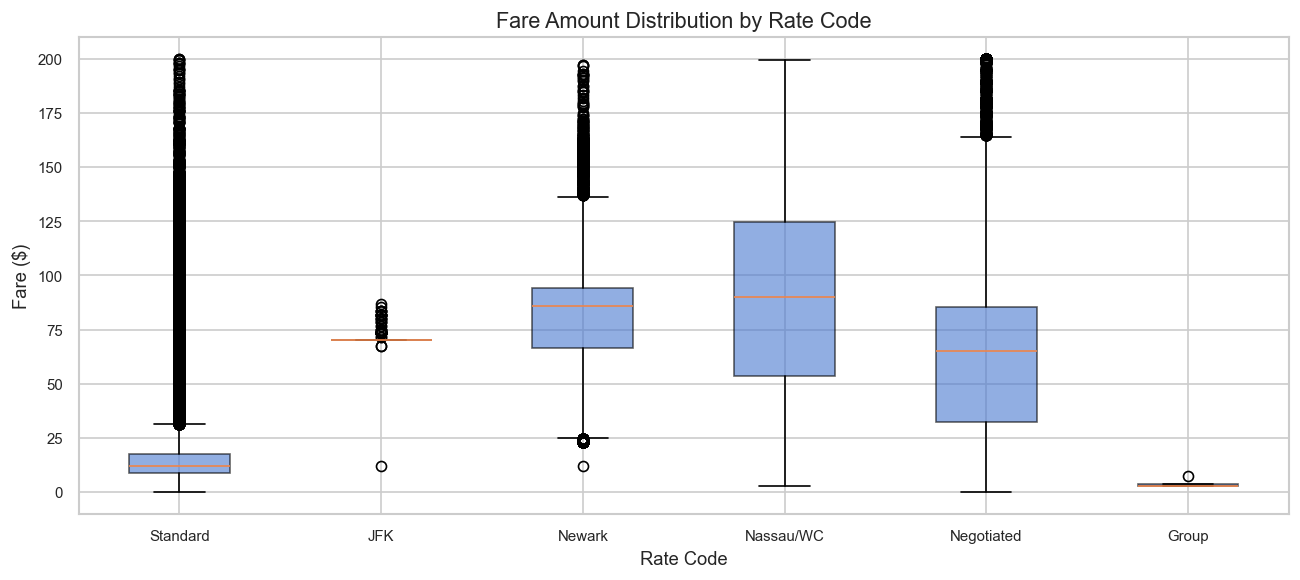

In [5]:
RATE_SHORT = {1:'Standard',2:'JFK',3:'Newark',4:'Nassau/WC',5:'Negotiated',6:'Group'}

rate_fare = (
    df_clean[(df_clean.fare_amount > 0) & (df_clean.fare_amount <= 200) & df_clean.RatecodeID.isin(RATE_SHORT.keys())]
    .assign(rate_label=lambda x: x['RatecodeID'].astype(int).map(RATE_SHORT))
)

fig, ax = plt.subplots(figsize=(11, 5))
rate_groups = [rate_fare[rate_fare['rate_label'] == lbl]['fare_amount']
               for lbl in RATE_SHORT.values()]
ax.boxplot(rate_groups, labels=list(RATE_SHORT.values()), patch_artist=True,
           boxprops=dict(alpha=0.6))
ax.set_title('Fare Amount Distribution by Rate Code')
ax.set_xlabel('Rate Code')
ax.set_ylabel('Fare ($)')
plt.tight_layout()
plt.show()

Top Pickup Zones vs Revenue

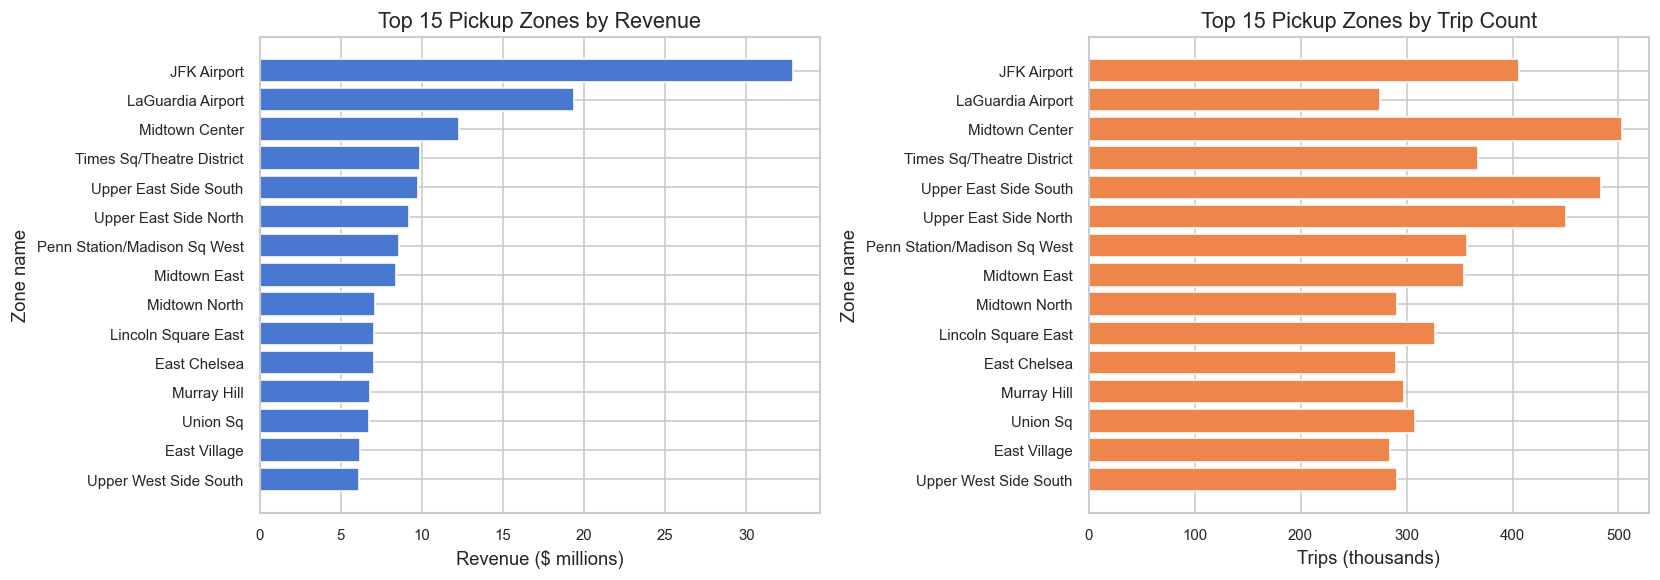

In [24]:
zone_rev = (
    df_clean[df_clean.total_amount > 0]
    .groupby('PUZone')
    .agg(trips=('trip_id','count'), revenue=('total_amount','sum'))
    .reset_index()
    .sort_values('revenue', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(zone_rev['PUZone'].astype(str)[::-1],
             zone_rev['revenue'][::-1] / 1e6, color=PALETTE[0])
axes[0].set_title('Top 15 Pickup Zones by Revenue')
axes[0].set_xlabel('Revenue ($ millions)')
axes[0].set_ylabel('Zone name')

axes[1].barh(zone_rev['PUZone'].astype(str)[::-1],
             zone_rev['trips'][::-1] / 1000, color=PALETTE[1])
axes[1].set_title('Top 15 Pickup Zones by Trip Count')
axes[1].set_xlabel('Trips (thousands)')
axes[1].set_ylabel('Zone name')
plt.tight_layout()
plt.show()

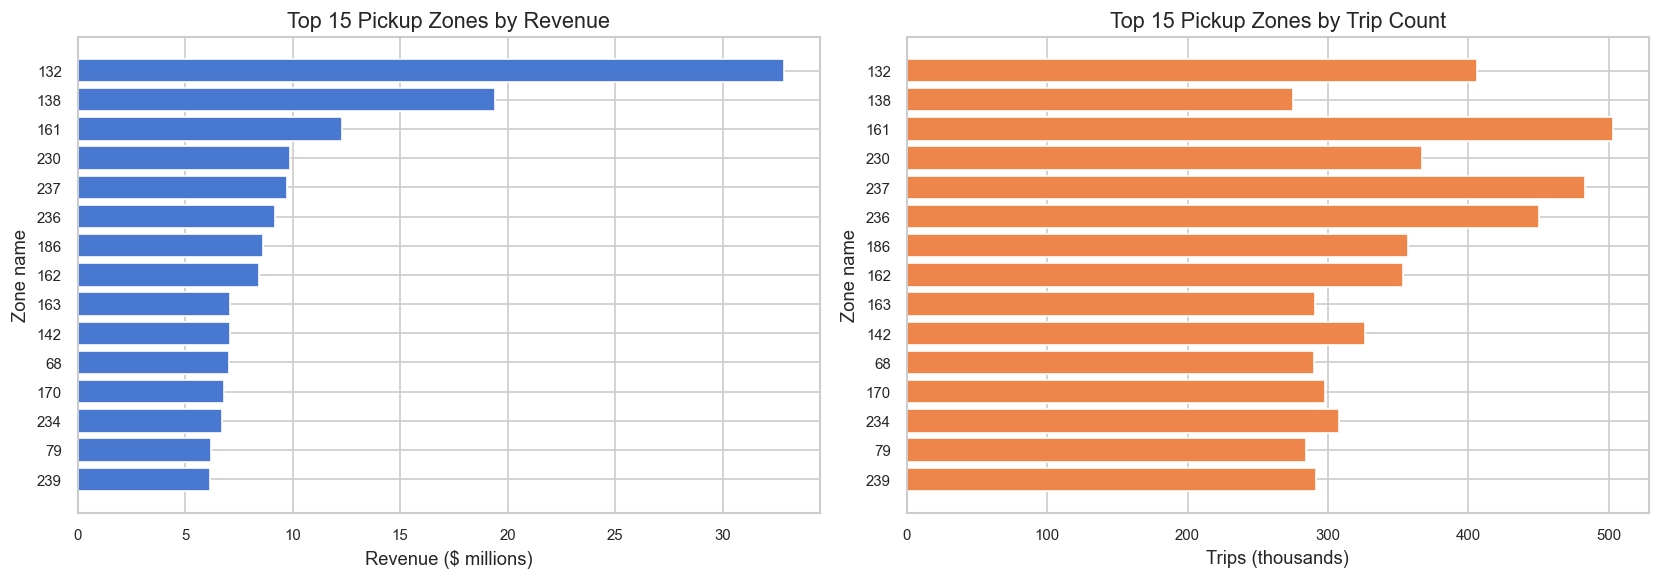

In [27]:
zone_rev = (
    df_clean[df_clean.total_amount > 0]
    .groupby('PULocationID')
    .agg(trips=('trip_id','count'), revenue=('total_amount','sum'))
    .reset_index()
    .sort_values('revenue', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(zone_rev['PULocationID'].astype(str)[::-1],
             zone_rev['revenue'][::-1] / 1e6, color=PALETTE[0])
axes[0].set_title('Top 15 Pickup Zones by Revenue')
axes[0].set_xlabel('Revenue ($ millions)')
axes[0].set_ylabel('Zone name')

axes[1].barh(zone_rev['PULocationID'].astype(str)[::-1],
             zone_rev['trips'][::-1] / 1000, color=PALETTE[1])
axes[1].set_title('Top 15 Pickup Zones by Trip Count')
axes[1].set_xlabel('Trips (thousands)')
axes[1].set_ylabel('Zone name')
plt.tight_layout()
plt.show()

Month × Hour Trip Volume Heatmap

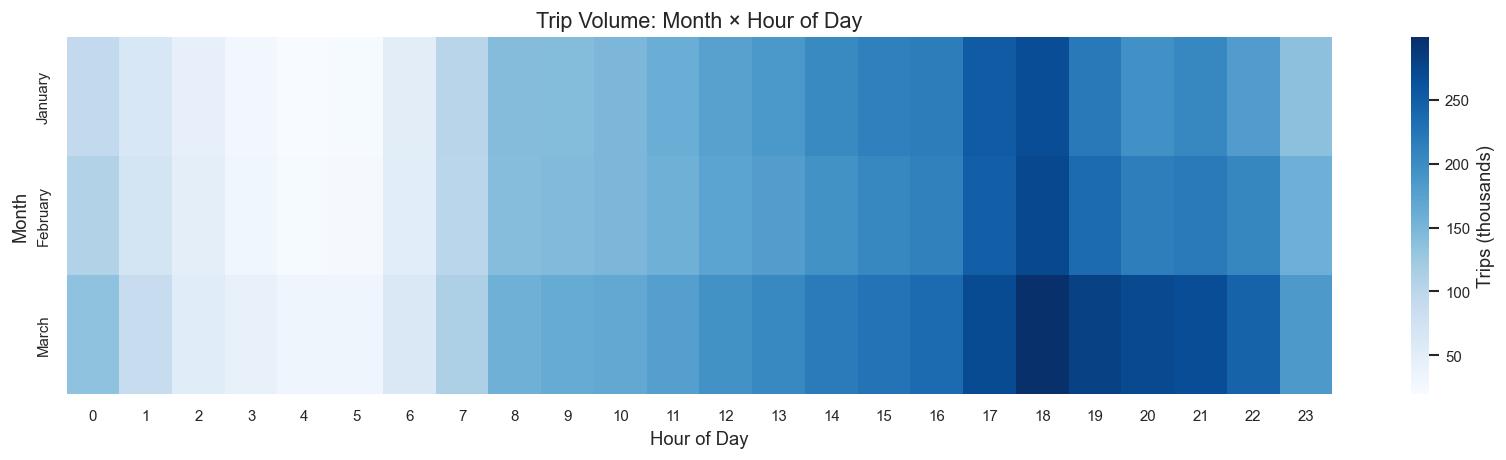

In [14]:
df_clean['pickup_month'] = df_clean['tpep_pickup_datetime'].dt.to_period('M').astype(str)
df_clean['pickup_hour'] = df_clean['tpep_pickup_datetime'].dt.hour

pivot_mh = (
    df_clean.groupby(['pickup_month', 'pickup_hour'])
    .size()
    .unstack()
)
pivot_mh.index = ['January','February','March']

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot_mh / 1000, ax=ax, cmap='Blues',
            cbar_kws={'label': 'Trips (thousands)'})
ax.set_title('Trip Volume: Month × Hour of Day')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Month')
plt.tight_layout()
plt.show()

Distance × Duration × Total Amount (3-var scatter)

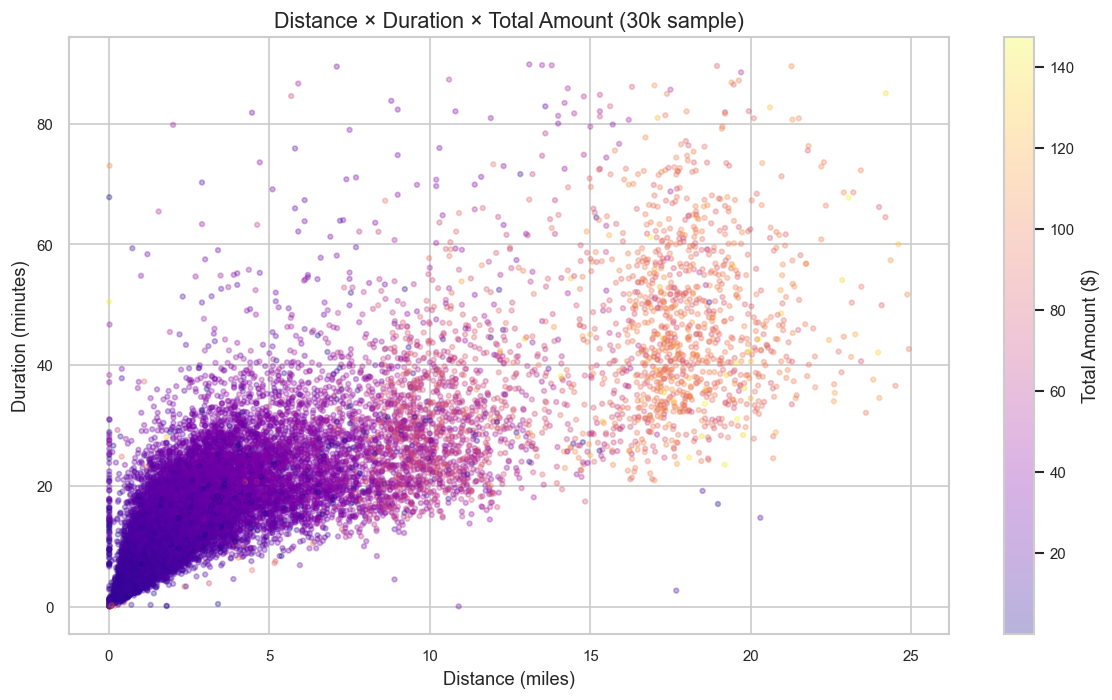

In [15]:
s3 = df_clean[
    (df_clean.trip_distance > 0) & (df_clean.trip_distance <= 25) &
    (df_clean.trip_duration_min > 0) & (df_clean.trip_duration_min <= 90) &
    (df_clean.total_amount > 0) & (df_clean.total_amount <= 150)
].sample(30_000, random_state=7)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(
    s3['trip_distance'], s3['trip_duration_min'],
    c=s3['total_amount'], cmap='plasma', alpha=0.3, s=8
)
cb = fig.colorbar(sc, ax=ax)
cb.set_label('Total Amount ($)')
ax.set_title('Distance × Duration × Total Amount (30k sample)')
ax.set_xlabel('Distance (miles)')
ax.set_ylabel('Duration (minutes)')
plt.tight_layout()
plt.show()

PC      Explained Var   Cumulative
PC1            88.67%       88.67%
PC2             8.01%       96.67%
PC3             3.33%      100.00%

Loadings (how much each variable contributes to each PC):
                     PC1    PC2    PC3
trip_distance      0.588 -0.333  0.737
trip_duration_min  0.561  0.825 -0.074
total_amount       0.583 -0.457 -0.671


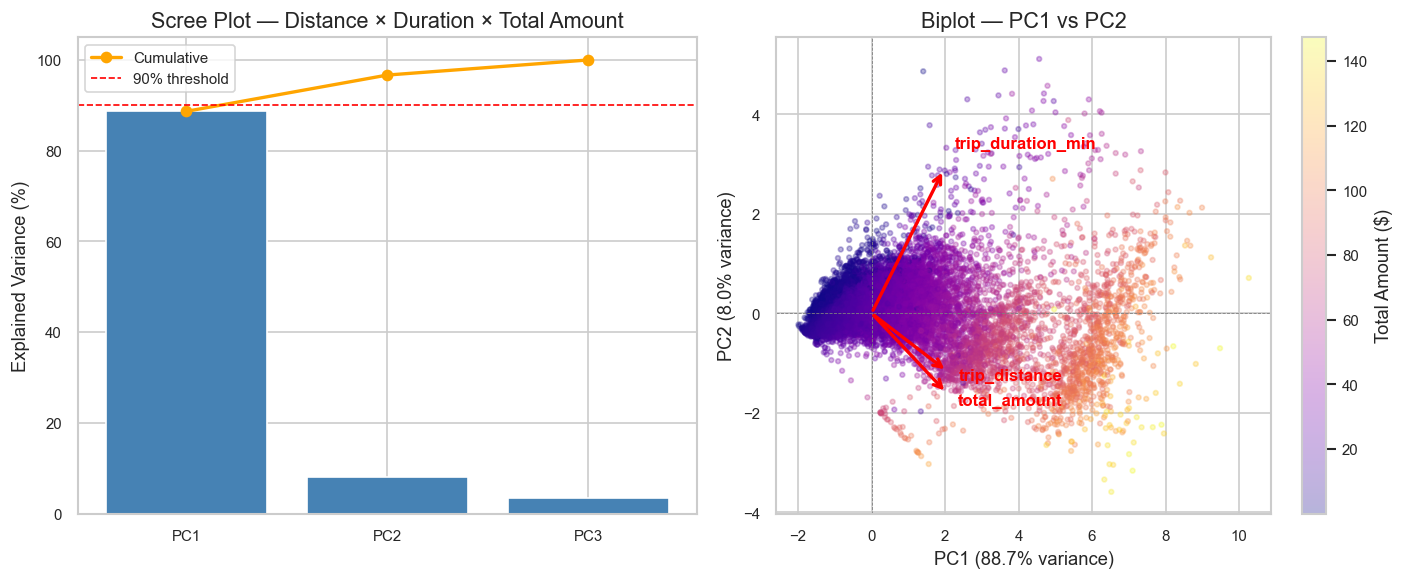

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# ── 1. Sample (same as your scatter) ────────────────────────────────────────
s3 = df_clean[
    (df_clean.trip_distance     >  0) & (df_clean.trip_distance     <= 25) &
    (df_clean.trip_duration_min >  0) & (df_clean.trip_duration_min <= 90) &
    (df_clean.total_amount      >  0) & (df_clean.total_amount      <= 150)
].sample(30_000, random_state=7)

# ── 2. Select & scale the three variables ───────────────────────────────────
features = ['trip_distance', 'trip_duration_min', 'total_amount']
X = s3[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)   # mean=0, std=1 for each column

# ── 3. Fit PCA ───────────────────────────────────────────────────────────────
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_          # e.g. [0.72, 0.21, 0.07]
cumulative = np.cumsum(explained)

# ── 4. Print variance summary ────────────────────────────────────────────────
print("=" * 45)
print(f"{'PC':<6} {'Explained Var':>14} {'Cumulative':>12}")
print("=" * 45)
for i, (e, c) in enumerate(zip(explained, cumulative), 1):
    print(f"PC{i:<4} {e*100:>13.2f}%  {c*100:>10.2f}%")
print("=" * 45)

# ── 5. Loadings table ────────────────────────────────────────────────────────
import pandas as pd
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=['PC1', 'PC2', 'PC3']
).round(3)
print("\nLoadings (how much each variable contributes to each PC):")
print(loadings)

# ── 6. Scree plot ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['PC1', 'PC2', 'PC3'], explained * 100, color='steelblue', edgecolor='white')
axes[0].plot(['PC1', 'PC2', 'PC3'], cumulative * 100,
             color='orange', marker='o', linewidth=2, label='Cumulative')
axes[0].axhline(90, color='red', linestyle='--', linewidth=1, label='90% threshold')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot — Distance × Duration × Total Amount')
axes[0].legend()
axes[0].set_ylim(0, 105)

# ── 7. Biplot (PC1 vs PC2, coloured by total_amount) ─────────────────────────
sc = axes[1].scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=s3['total_amount'].values,
    cmap='plasma', alpha=0.3, s=8
)
cb = fig.colorbar(sc, ax=axes[1])
cb.set_label('Total Amount ($)')

# Overlay loading arrows
scale = 3.5   # arrow length scaling
for i, feat in enumerate(features):
    axes[1].annotate(
        '', 
        xy=(pca.components_[0, i] * scale,
            pca.components_[1, i] * scale),
        xytext=(0, 0),
        arrowprops=dict(arrowstyle='->', color='red', lw=2)
    )
    axes[1].text(
        pca.components_[0, i] * scale * 1.15,
        pca.components_[1, i] * scale * 1.15,
        feat, fontsize=10, color='red', fontweight='bold'
    )

axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
axes[1].set_title('Biplot — PC1 vs PC2')
axes[1].axhline(0, color='grey', linewidth=0.5, linestyle='--')
axes[1].axvline(0, color='grey', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

Top Zone × Payment Type × Revenue

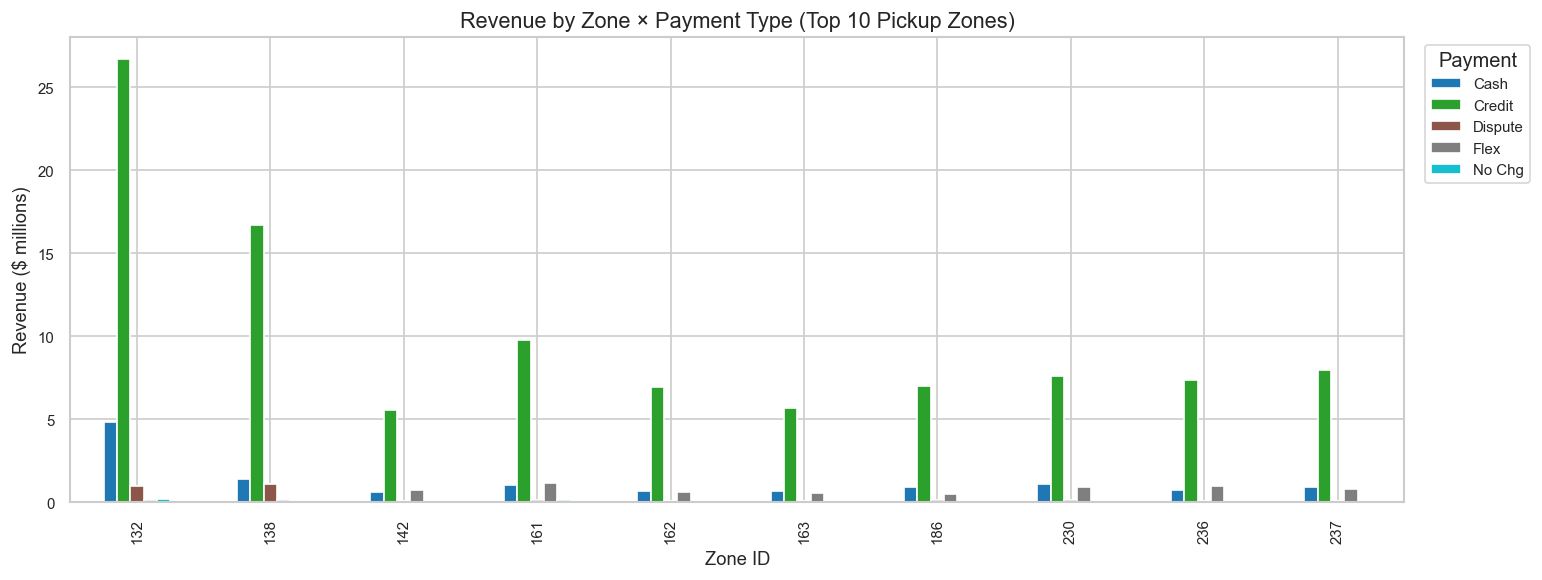

In [28]:

PAY_SHORT = {0:'Flex',1:'Credit',2:'Cash',3:'No Chg',4:'Dispute',5:'Unknown',6:'Voided'}

top_zones = zone_rev['PULocationID'].tolist()[:10]

zone_pay_rev = (
    df_clean[df_clean['PULocationID'].isin(top_zones) & (df_clean.total_amount > 0)]
    .assign(pay_label=lambda x: x['payment_type'].map(PAY_SHORT))
    .groupby(['PULocationID', 'pay_label'])['total_amount']
    .sum()
    .unstack(fill_value=0)
)

zone_pay_rev.index = zone_pay_rev.index.astype(str)

fig, ax = plt.subplots(figsize=(13, 5))
zone_pay_rev.div(1e6).plot(kind='bar', ax=ax, colormap='tab10')
ax.set_title('Revenue by Zone × Payment Type (Top 10 Pickup Zones)')
ax.set_xlabel('Zone ID')
ax.set_ylabel('Revenue ($ millions)')
ax.legend(title='Payment', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

Correlation Matrix (Numeric Columns)

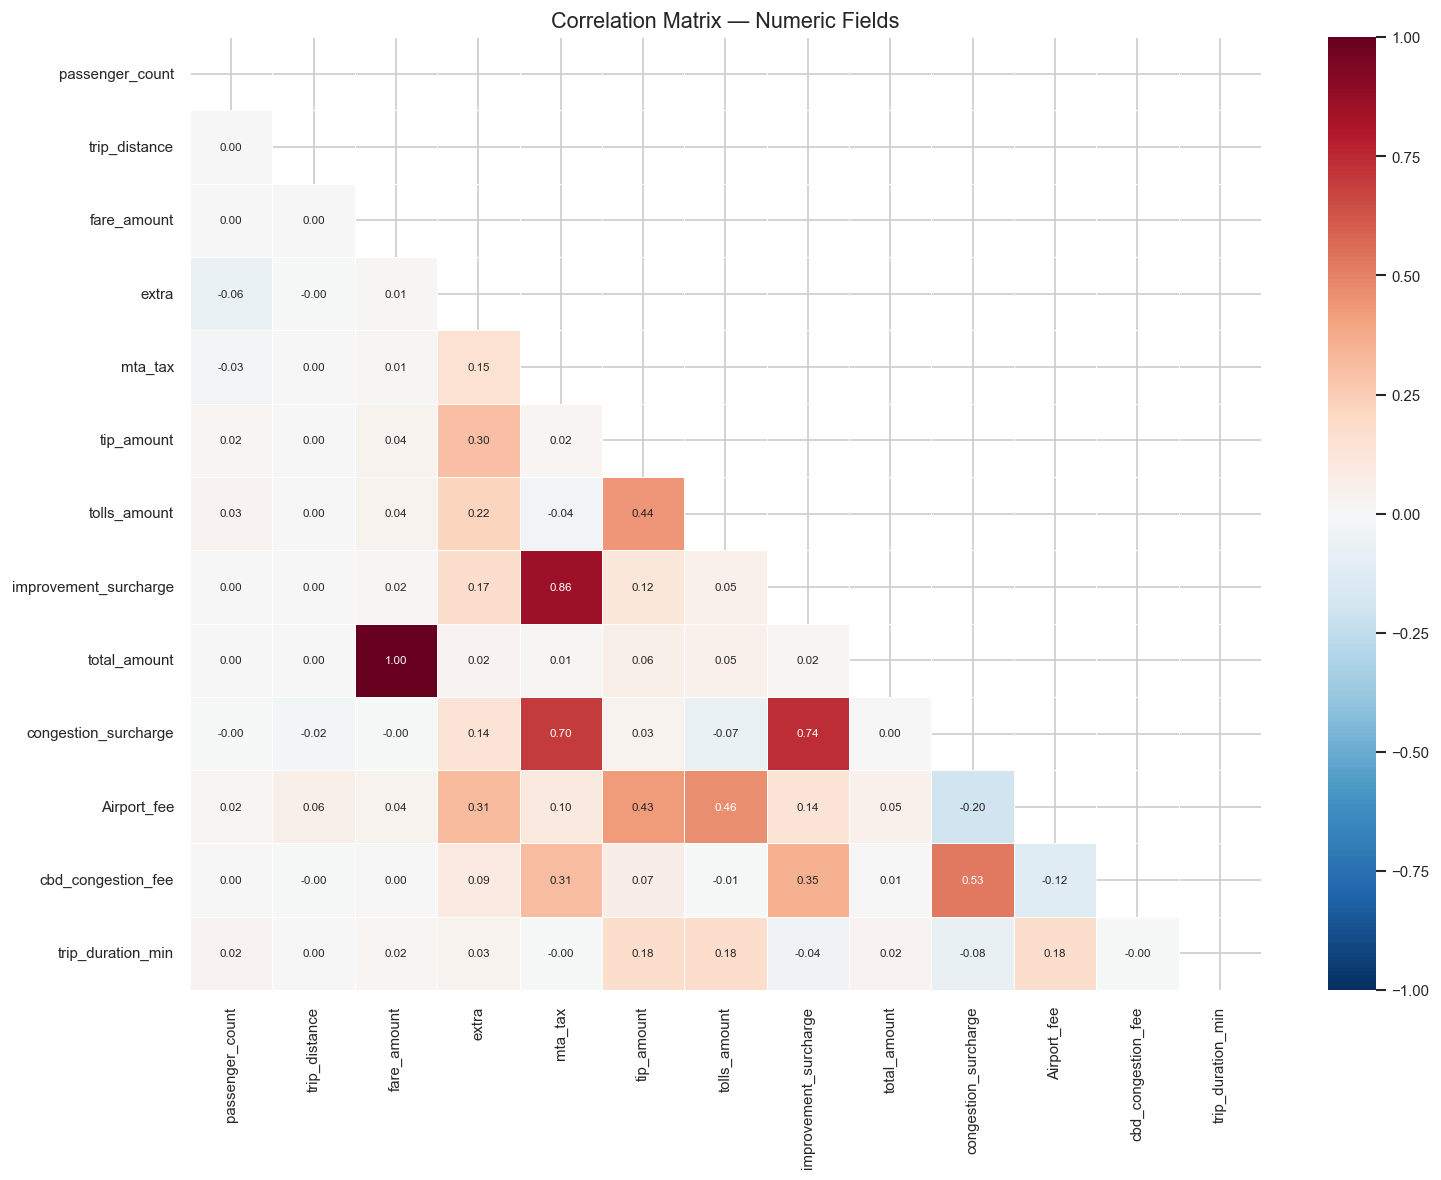

In [29]:
num_cols = ['passenger_count','trip_distance','fare_amount','extra',
            'mta_tax','tip_amount','tolls_amount','improvement_surcharge',
            'total_amount','congestion_surcharge','Airport_fee',
            'cbd_congestion_fee','trip_duration_min']

corr = df_clean[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, ax=ax, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={'size': 7}
)
ax.set_title('Correlation Matrix — Numeric Fields')
plt.tight_layout()
plt.show()

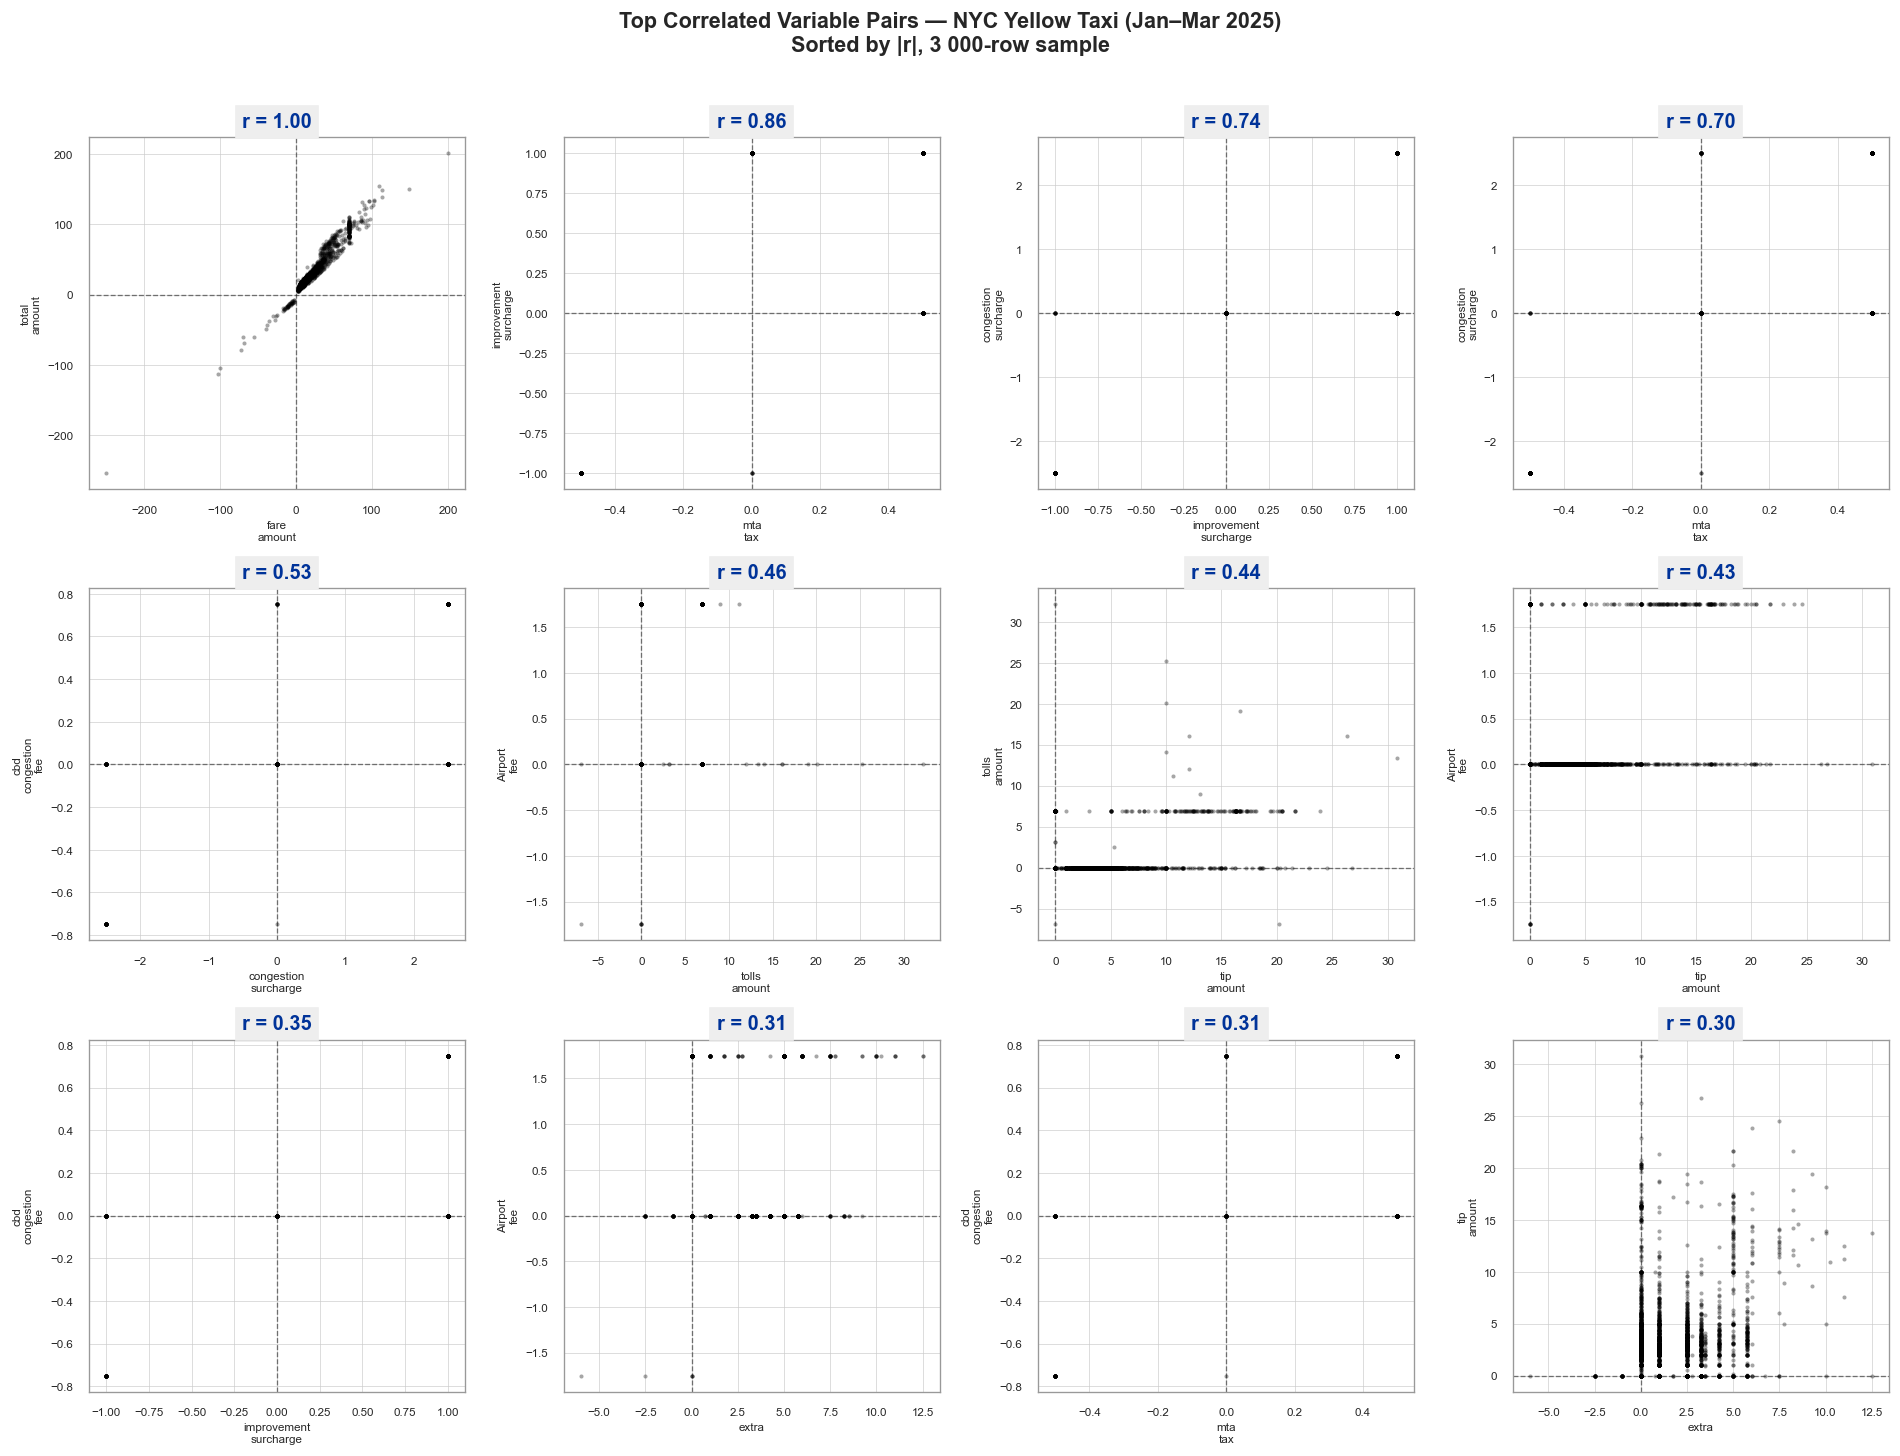

In [46]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import seaborn as sns

num_cols = ['passenger_count','trip_distance','fare_amount','extra',
            'mta_tax','tip_amount','tolls_amount','improvement_surcharge',
            'total_amount','congestion_surcharge','Airport_fee',
            'cbd_congestion_fee','trip_duration_min']

# ── 1. Compute full correlation matrix ───────────────────────────────────────
corr = df_clean[num_cols].corr()

# ── 2. Extract all unique pairs with their correlation values ────────────────
pairs = []
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        r = corr.loc[num_cols[i], num_cols[j]]
        pairs.append((r, num_cols[i], num_cols[j]))

# ── 3. Sort by absolute correlation and pick top 12 pairs ───────────────────
pairs_sorted = sorted(pairs, key=lambda x: abs(x[0]), reverse=True)
top_pairs    = pairs_sorted[:12]   # change to show more/fewer panels

# ── 4. Sample for speed ──────────────────────────────────────────────────────
sample = df_clean[num_cols].dropna().sample(
    min(3000, len(df_clean)), random_state=42
)

# ── 5. Draw scatter grid ─────────────────────────────────────────────────────
ncols = 4
nrows = int(np.ceil(len(top_pairs) / ncols))

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 4, nrows * 4),
                         facecolor='white')
axes = axes.flatten()

for idx, (r, col_x, col_y) in enumerate(top_pairs):
    ax = axes[idx]

    # Scatter points
    ax.scatter(
        sample[col_x], sample[col_y],
        s=6, alpha=0.35, color='black', linewidths=0
    )

    # Dashed crosshair lines (like the reference image)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

    # Color title by direction of correlation
    title_color = '#CC2200' if r < 0 else '#003399'
    ax.set_title(f'r = {r:.2f}', fontsize=12, fontweight='bold',
                 color=title_color,
                 backgroundcolor='#EEEEEE', pad=6)

    # Short axis labels
    ax.set_xlabel(col_x.replace('_', '\n'), fontsize=7, labelpad=3)
    ax.set_ylabel(col_y.replace('_', '\n'), fontsize=7, labelpad=3)

    # Grid styling — match reference
    ax.set_facecolor('white')
    ax.grid(True, linewidth=0.4, color='#CCCCCC')
    ax.tick_params(labelsize=7)

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
        spine.set_color('#999999')

# Hide unused panels
for idx in range(len(top_pairs), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(
    'Top Correlated Variable Pairs — NYC Yellow Taxi (Jan–Mar 2025)\n'
    'Sorted by |r|, 3 000-row sample',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('scatter_correlation_grid.png', dpi=160, bbox_inches='tight')
plt.show()

# PART 3 — TOR Required Questions

Univariate: Trip Volume Over Time

In [ ]:
import calendar
# This maps 1 -> Jan, 2 -> Feb, etc. automatically for any month
monthly_kpi['month'] = monthly_kpi['pickup_month'].apply(lambda x: calendar.month_name[x][:3])

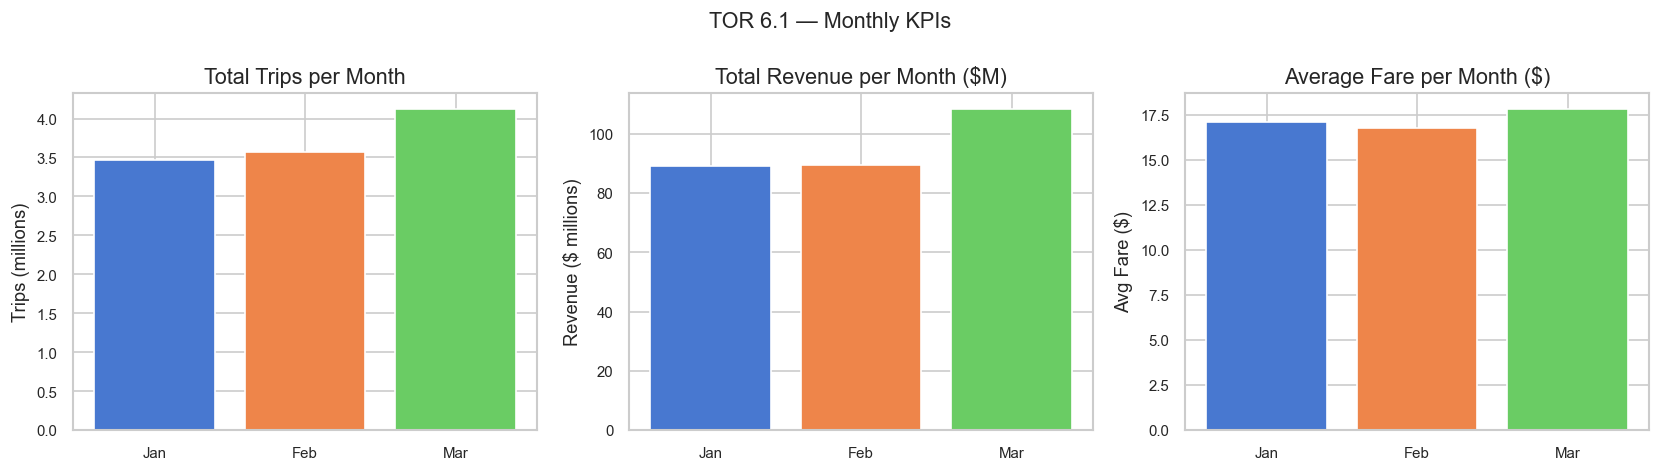

month   trips      revenue  avg_fare  avg_dist   avg_dur
  Jan 3473183  88958517.35 17.083109  5.857636 15.041867
  Feb 3572378  89424334.34 16.750741  6.031117 15.430212
  Mar 4122945 108311127.58 17.809495  6.603987 16.075640


In [41]:
# Monthly summary KPIs
monthly_kpi = (
    df_clean.groupby('pickup_month')
    .agg(
        trips=('trip_id','count'),
        revenue=('total_amount','sum'),
        avg_fare=('fare_amount','mean'),
        avg_dist=('trip_distance','mean'),
        avg_dur=('trip_duration_min','mean')
    )
    .reset_index()
)

monthly_kpi['month'] = monthly_kpi['pickup_month'].map({
    '2025-01': 'Jan',
    '2025-02': 'Feb',
    '2025-03': 'Mar'
})
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(monthly_kpi['month'], monthly_kpi['trips'] / 1e6, color=PALETTE[:3])
axes[0].set_title('Total Trips per Month')
axes[0].set_ylabel('Trips (millions)')

axes[1].bar(monthly_kpi['month'], monthly_kpi['revenue'] / 1e6, color=PALETTE[:3])
axes[1].set_title('Total Revenue per Month ($M)')
axes[1].set_ylabel('Revenue ($ millions)')

axes[2].bar(monthly_kpi['month'], monthly_kpi['avg_fare'], color=PALETTE[:3])
axes[2].set_title('Average Fare per Month ($)')
axes[2].set_ylabel('Avg Fare ($)')

plt.suptitle('TOR 6.1 — Monthly KPIs', fontsize=13)
plt.tight_layout()
plt.show()
print(monthly_kpi[['month','trips','revenue','avg_fare','avg_dist','avg_dur']].to_string(index=False))

Univariate: Distributions of Core Metrics

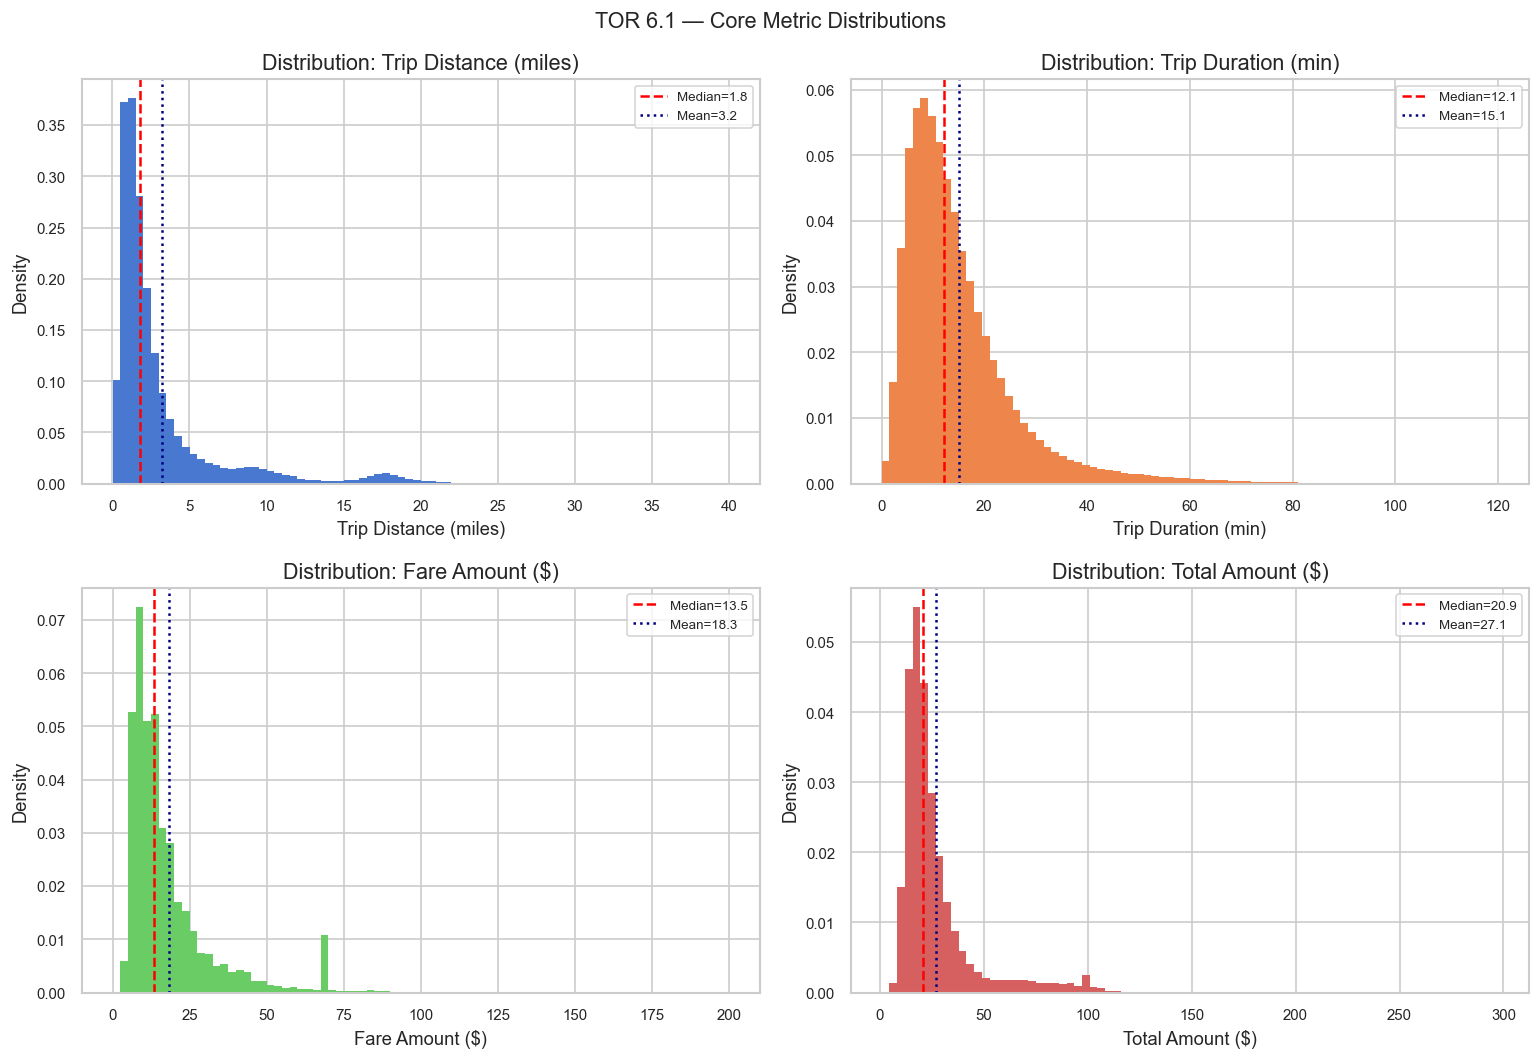

In [42]:
clean = df_clean[
    (df_clean.trip_distance > 0) & (df_clean.trip_distance <= 40) &
    (df_clean.trip_duration_min > 0) & (df_clean.trip_duration_min <= 120) &
    (df_clean.fare_amount > 0) & (df_clean.fare_amount <= 200) &
    (df_clean.total_amount > 0) & (df_clean.total_amount <= 300)
]

metrics = [
    ('trip_distance',    'Trip Distance (miles)'),
    ('trip_duration_min','Trip Duration (min)'),
    ('fare_amount',      'Fare Amount ($)'),
    ('total_amount',     'Total Amount ($)'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (col, lbl) in enumerate(metrics):
    axes[i].hist(clean[col], bins=80, color=PALETTE[i], edgecolor='none', density=True)
    axes[i].set_title(f'Distribution: {lbl}')
    axes[i].set_xlabel(lbl)
    axes[i].set_ylabel('Density')
    axes[i].axvline(clean[col].median(), color='red', ls='--',
                    label=f'Median={clean[col].median():.1f}')
    axes[i].axvline(clean[col].mean(), color='navy', ls=':',
                    label=f'Mean={clean[col].mean():.1f}')
    axes[i].legend(fontsize=8)

plt.suptitle('TOR 6.1 — Core Metric Distributions', fontsize=13)
plt.tight_layout()
plt.show()

Bivariate: Hour of Day vs Trip Volume


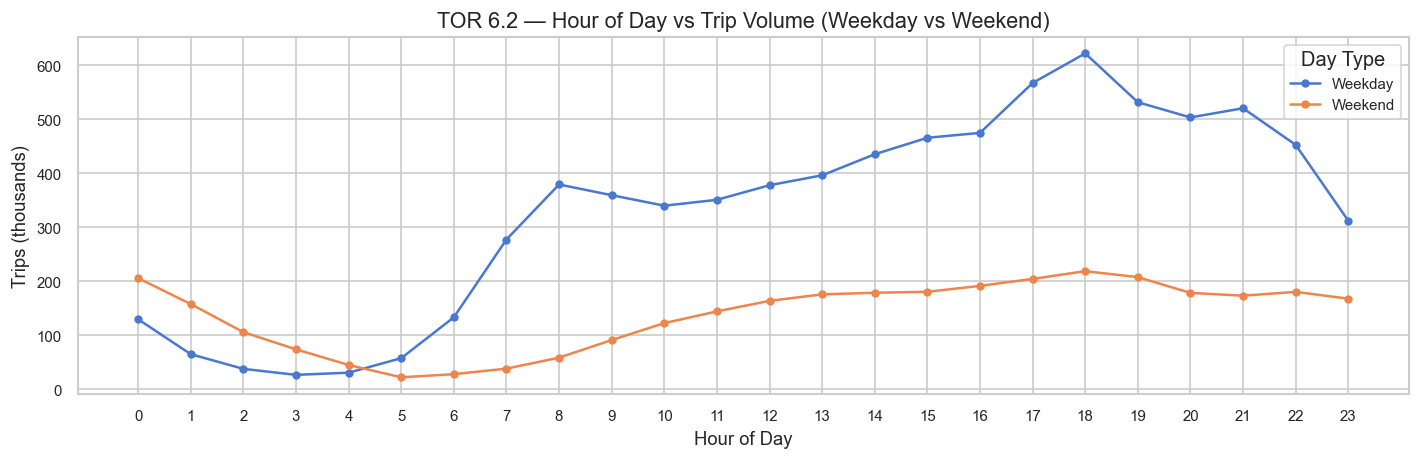

In [44]:
# Avg trips per hour per day type (weekday vs weekend)
df_clean['pickup_dow'] = df_clean['tpep_pickup_datetime'].dt.day_name()
df_clean['is_weekend'] = df_clean['pickup_dow'].isin(['Saturday','Sunday'])

hourly_type = (
    df_clean.groupby(['pickup_hour','is_weekend'])
    .size()
    .unstack()
    .rename(columns={False:'Weekday', True:'Weekend'})
)

fig, ax = plt.subplots(figsize=(12, 4))
hourly_type.div(1000).plot(ax=ax, marker='o', ms=4)
ax.set_title('TOR 6.2 — Hour of Day vs Trip Volume (Weekday vs Weekend)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Trips (thousands)')
ax.set_xticks(range(24))
ax.legend(title='Day Type')
plt.tight_layout()
plt.show()

Bivariate: Geography vs Revenue & Trip Count

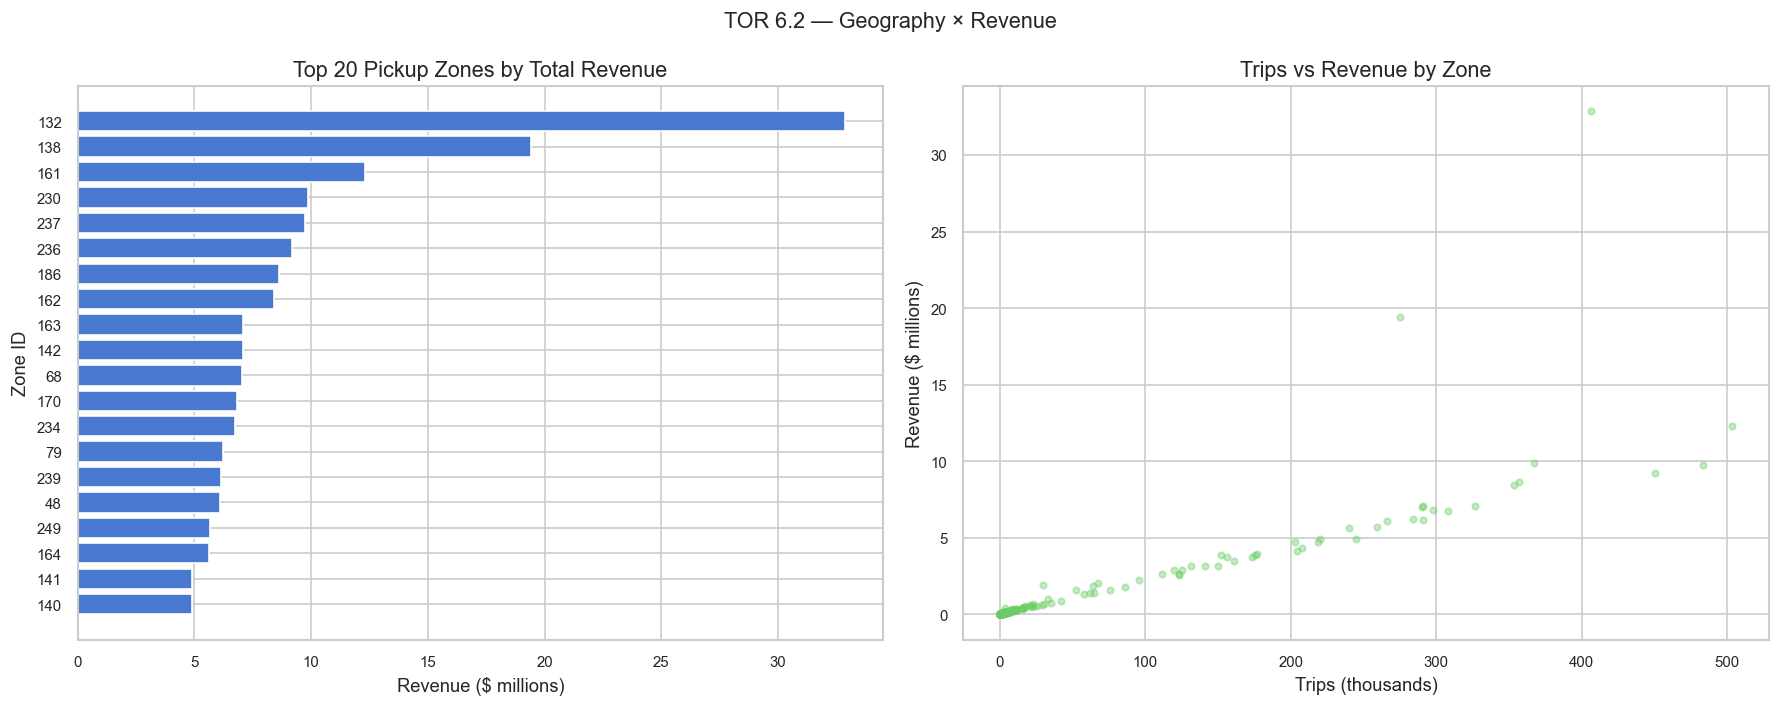

In [45]:
geo_rev = (
    df_clean[df_clean.total_amount > 0]
    .groupby('PULocationID')
    .agg(trips=('trip_id','count'), revenue=('total_amount','sum'),
         avg_total=('total_amount','mean'))
    .reset_index()
    .sort_values('revenue', ascending=False)
)

top20 = geo_rev.head(20)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].barh(top20['PULocationID'].astype(str)[::-1],
             top20['revenue'][::-1] / 1e6, color=PALETTE[0])
axes[0].set_title('Top 20 Pickup Zones by Total Revenue')
axes[0].set_xlabel('Revenue ($ millions)')
axes[0].set_ylabel('Zone ID')

axes[1].scatter(geo_rev['trips'] / 1000, geo_rev['revenue'] / 1e6,
                alpha=0.4, s=15, color=PALETTE[2])
axes[1].set_title('Trips vs Revenue by Zone')
axes[1].set_xlabel('Trips (thousands)')
axes[1].set_ylabel('Revenue ($ millions)')

plt.suptitle('TOR 6.2 — Geography × Revenue', fontsize=13)
plt.tight_layout()
plt.show()

Bivariate: Payment Type vs Tip & Total

Payment Type Summary:
pay_label   trips  med_tip  med_total  tip_rate
   Credit 7460419      3.2      21.17 93.896630
     Flex 2259617      0.0      19.83  8.444396
     Cash 1086773      0.0      17.15  0.006073
  Dispute  125272      0.0      17.55  0.118941
   No Chg   47821      0.0      14.35  0.345037


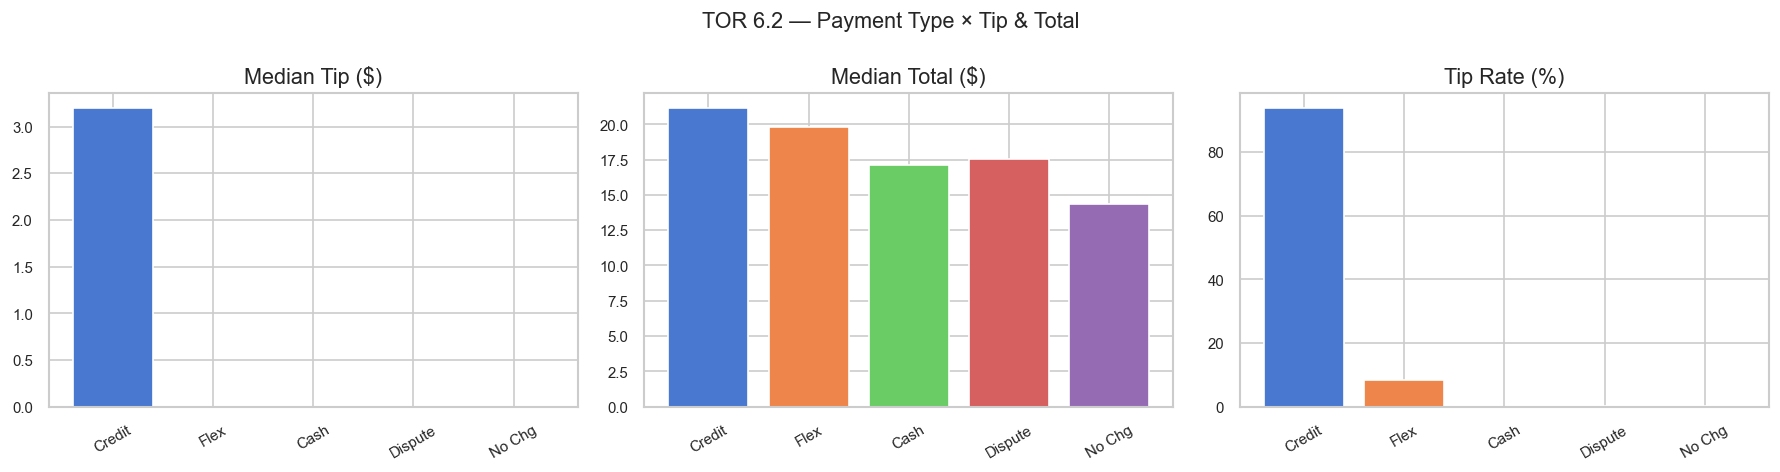

In [48]:
pay_stats = (
    df_clean[df_clean.total_amount.between(0.01, 500)]
    .assign(pay_label=lambda x: x['payment_type'].map(PAY_SHORT))
    .groupby('pay_label')
    .agg(
        trips=('trip_id','count'),
        med_tip=('tip_amount','median'),
        med_total=('total_amount','median'),
        tip_rate=('tip_amount', lambda x: (x > 0).mean() * 100)
    )
    .reset_index()
    .sort_values('trips', ascending=False)
)

print('Payment Type Summary:')
print(pay_stats.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(pay_stats['pay_label'], pay_stats['med_tip'], color=PALETTE[:len(pay_stats)])
axes[0].set_title('Median Tip ($)')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(pay_stats['pay_label'], pay_stats['med_total'], color=PALETTE[:len(pay_stats)])
axes[1].set_title('Median Total ($)')
axes[1].tick_params(axis='x', rotation=30)

axes[2].bar(pay_stats['pay_label'], pay_stats['tip_rate'], color=PALETTE[:len(pay_stats)])
axes[2].set_title('Tip Rate (%)')
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('TOR 6.2 — Payment Type × Tip & Total', fontsize=13)
plt.tight_layout()
plt.show()

Multivariate: Time × Geography × Demand

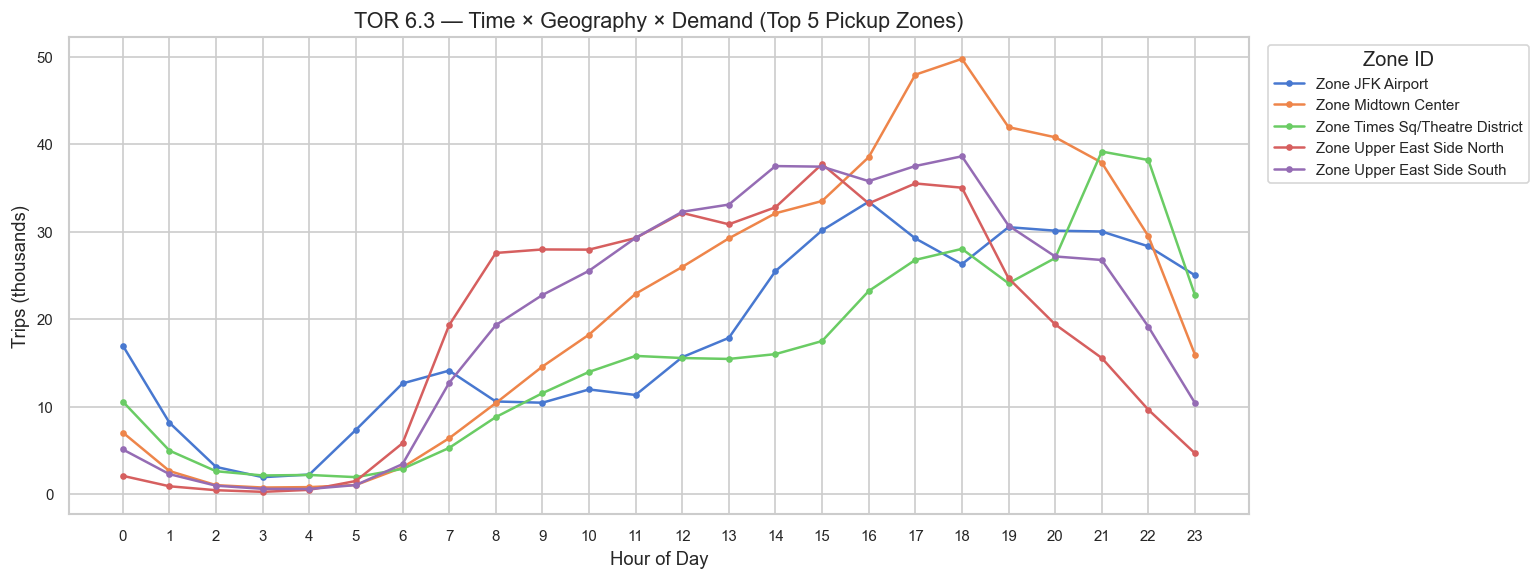

In [51]:
top5_zones = df_clean['PUZone'].value_counts().head(5).index.tolist()

tgd = (
    df_clean[df_clean['PUZone'].isin(top5_zones)]
    .groupby(['PUZone','pickup_hour'])
    .size()
    .unstack()
)

fig, ax = plt.subplots(figsize=(13, 5))
for zone in tgd.index:
    ax.plot(tgd.columns, tgd.loc[zone] / 1000, marker='o', ms=3, label=f'Zone {zone}')

ax.set_title('TOR 6.3 — Time × Geography × Demand (Top 5 Pickup Zones)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Trips (thousands)')
ax.set_xticks(range(24))
ax.legend(title='Zone ID', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

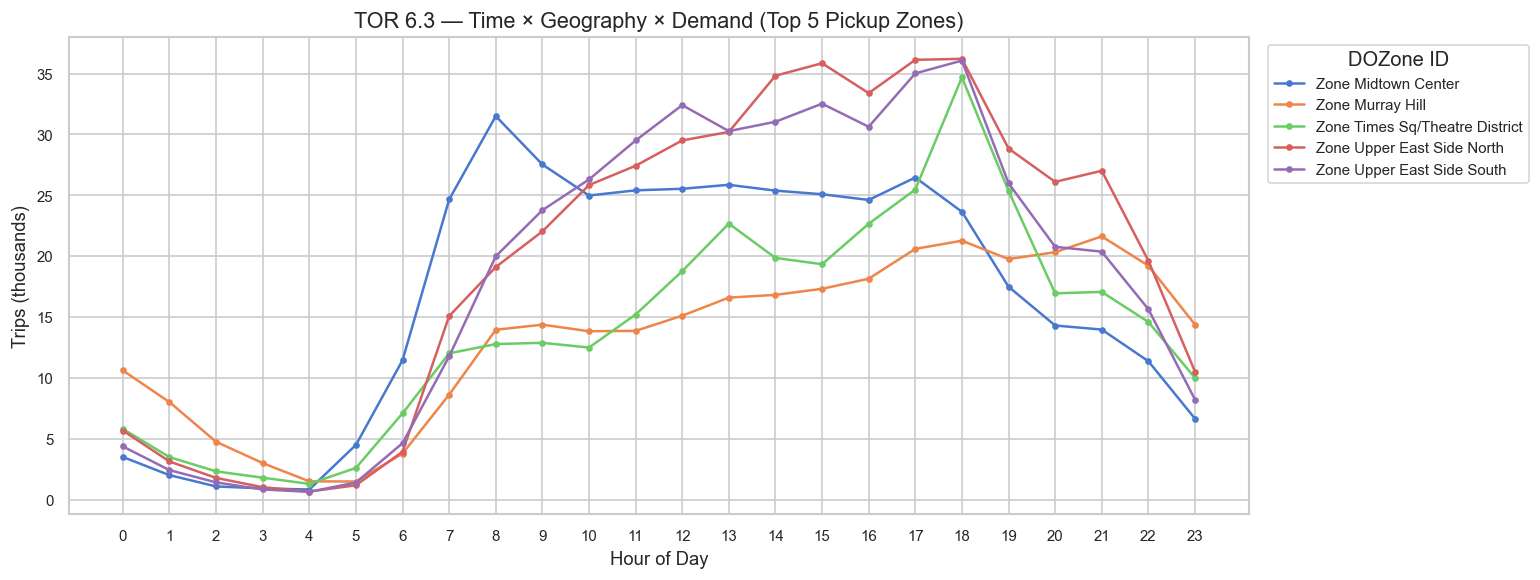

In [52]:
top5_zones = df_clean['DOZone'].value_counts().head(5).index.tolist()

tgd = (
    df_clean[df_clean['DOZone'].isin(top5_zones)]
    .groupby(['DOZone','pickup_hour'])
    .size()
    .unstack()
)

fig, ax = plt.subplots(figsize=(13, 5))
for zone in tgd.index:
    ax.plot(tgd.columns, tgd.loc[zone] / 1000, marker='o', ms=3, label=f'Zone {zone}')

ax.set_title('TOR 6.3 — Time × Geography × Demand (Top 5 Pickup Zones)')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Trips (thousands)')
ax.set_xticks(range(24))
ax.legend(title='DOZone ID', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

Multivariate: Geography × Payment Type × Revenue

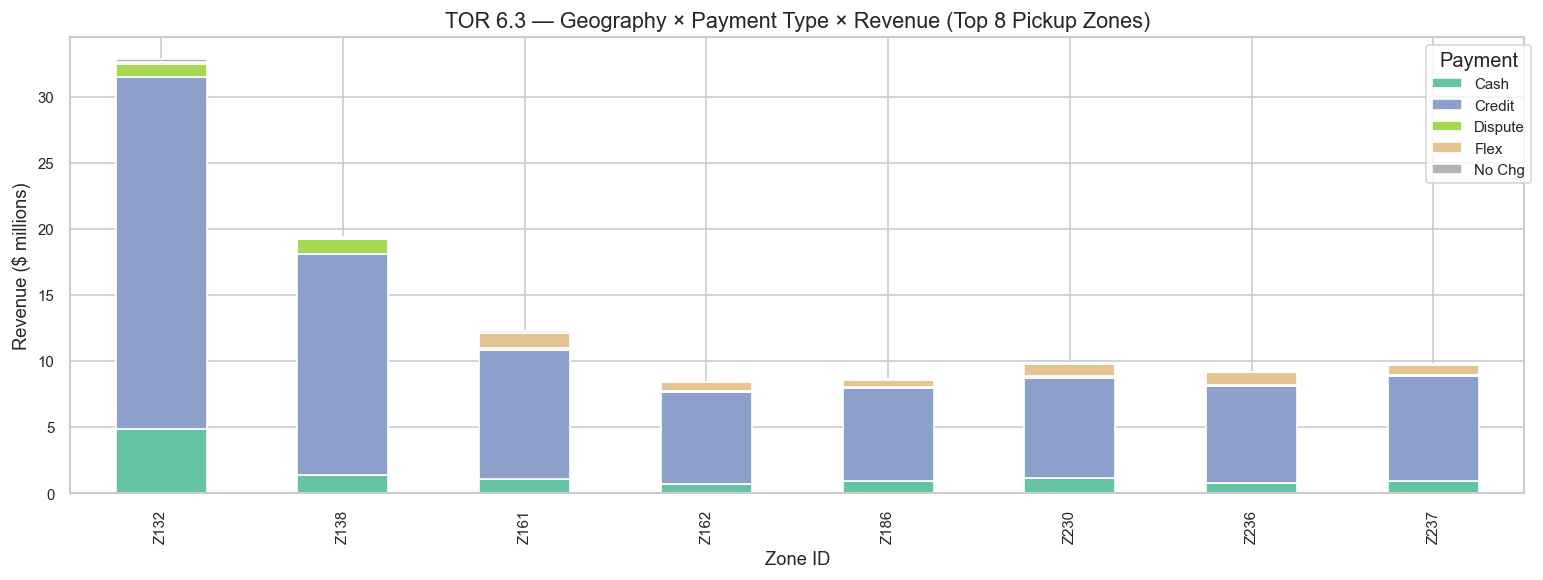

In [ ]:
top8_zones = geo_rev.head(8)['PULocationID'].tolist()

gpr = (
    df_clean[df_clean['PULocationID'].isin(top8_zones) & (df.total_amount > 0)]
    .assign(pay_label=lambda x: x['payment_type'].map(PAY_SHORT))
    .groupby(['PULocationID','pay_label'])['total_amount']
    .sum()
    .unstack(fill_value=0)
)
gpr.index = [f'Z{z}' for z in gpr.index]

fig, ax = plt.subplots(figsize=(13, 5))
gpr.div(1e6).plot(kind='bar', ax=ax, colormap='Set2', stacked=True)
ax.set_title('TOR 6.3 — Geography × Payment Type × Revenue (Top 8 Pickup Zones)')
ax.set_xlabel('Zone ID')
ax.set_ylabel('Revenue ($ millions)')
ax.legend(title='Payment', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

Multivariate: Month × Hour × Demand

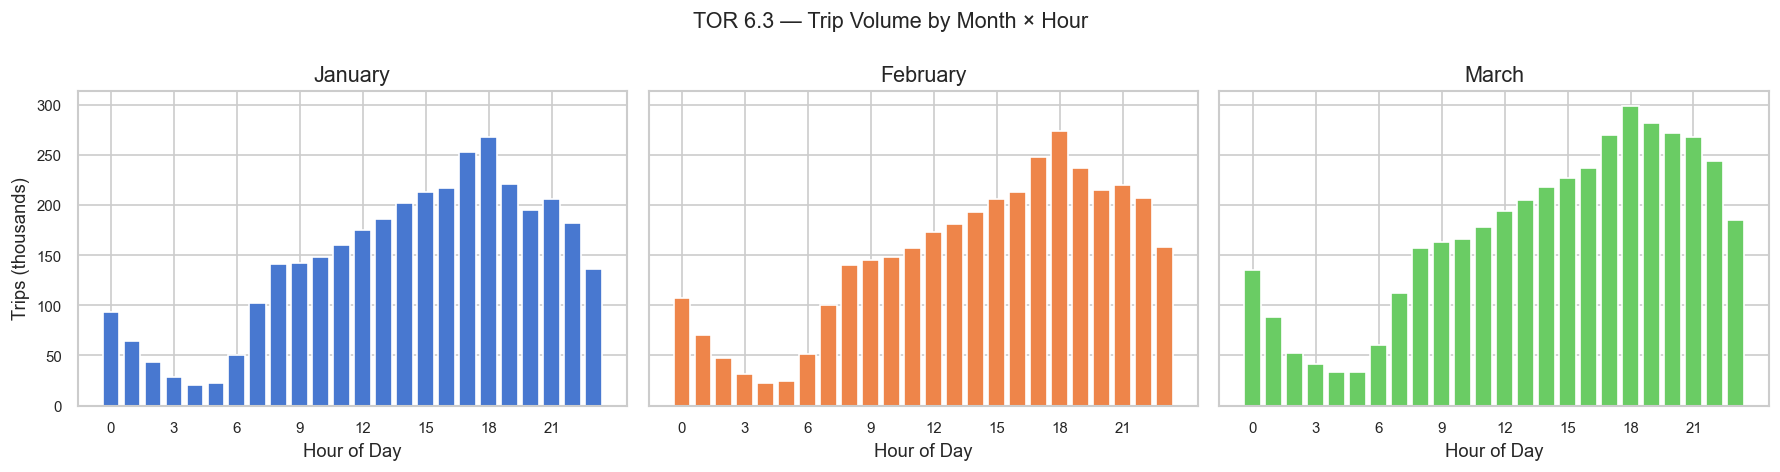

In [56]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

month_map = {
    '2025-01': 'January',
    '2025-02': 'February',
    '2025-03': 'March'
}

for i, (m, mname) in enumerate(month_map.items()):
    month_data = df_clean[df_clean['pickup_month'] == m]
    hourly_m = month_data.groupby('pickup_hour').size()
    axes[i].bar(hourly_m.index, hourly_m.values / 1000, color=PALETTE[i])
    axes[i].set_title(mname)
    axes[i].set_xlabel('Hour of Day')
    if i == 0:
        axes[i].set_ylabel('Trips (thousands)')
    axes[i].set_xticks(range(0, 24, 3))

plt.suptitle('TOR 6.3 — Trip Volume by Month × Hour', fontsize=13)
plt.tight_layout()
plt.show()

 Sensitivity Analysis — Impact of Cleaning Choices

=== Sensitivity Analysis ===
                Scenario    Trips  Avg Fare ($)  Avg Total ($)  Avg Dist (mi)
             All Records 11168506         17.24          25.67           6.19
    Remove Negative Fare 10633038         18.63          27.30           5.70
    Remove Zero Distance 10876240         17.23          25.72           6.35
Remove Negative Duration 11168506         17.24          25.67           6.19
       All Three Filters 10388498         18.52          27.26           5.83


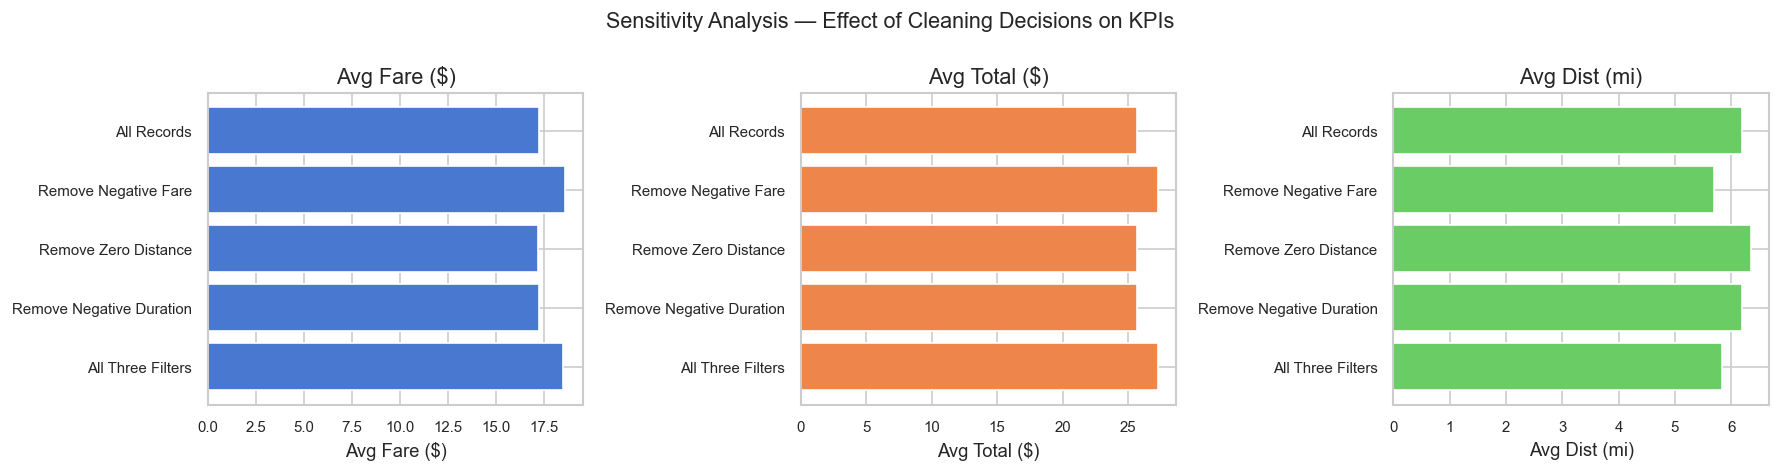

In [57]:
# Sensitivity: Does removing 'impossible' trips change headline KPIs?
scenarios = {
    'All Records': df_clean,
    'Remove Negative Fare': df_clean[df_clean.fare_amount >= 0],
    'Remove Zero Distance': df_clean[df_clean.trip_distance > 0],
    'Remove Negative Duration': df_clean[df_clean.trip_duration_min > 0],
    'All Three Filters': df_clean[
        (df_clean.fare_amount >= 0) &
        (df_clean.trip_distance > 0) &
        (df_clean.trip_duration_min > 0)
    ]
}

rows = []
for name, data in scenarios.items():
    rows.append({
        'Scenario': name,
        'Trips': len(data),
        'Avg Fare ($)': data.fare_amount.mean().round(2),
        'Avg Total ($)': data.total_amount.mean().round(2),
        'Avg Dist (mi)': data.trip_distance.mean().round(2),
    })

sens = pd.DataFrame(rows)
print('=== Sensitivity Analysis ===')
print(sens.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics_sens = ['Avg Fare ($)', 'Avg Total ($)', 'Avg Dist (mi)']
for i, m in enumerate(metrics_sens):
    axes[i].barh(sens['Scenario'][::-1], sens[m][::-1], color=PALETTE[i])
    axes[i].set_title(m)
    axes[i].set_xlabel(m)

plt.suptitle('Sensitivity Analysis — Effect of Cleaning Decisions on KPIs', fontsize=13)
plt.tight_layout()
plt.show()

Data Quality Summary

Total rows: 11,198,026

=== Data Quality Issues ===
                      Issue   Count  % of Total
    Missing passenger_count 2263178      20.211
         Missing RatecodeID 2263178      20.211
       Negative fare_amount  535468       4.782
         Zero trip_distance  292266       2.610
      Negative total_amount  186894       1.669
       Zero passenger_count   68620       0.613
       CBD fee before Jan 5     401       0.004
        Negative tip_amount     359       0.003
     Negative trip duration       0       0.000
         Zero trip duration       0       0.000
Pickup outside Jan-Mar 2025       0       0.000
         Invalid RatecodeID       0       0.000


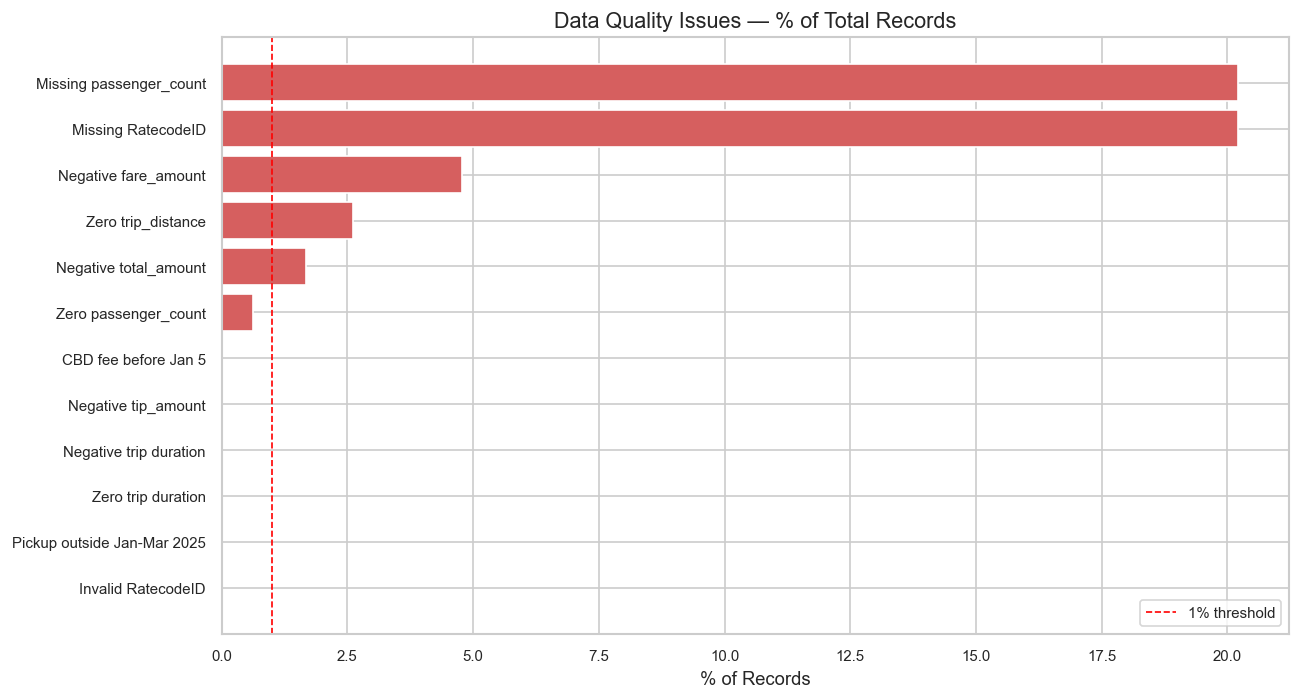

In [58]:
total = len(df)

issues = [
    ('Negative fare_amount',        (df_clean.fare_amount < 0).sum()),
    ('Zero trip_distance',          (df_clean.trip_distance == 0).sum()),
    ('Negative trip duration',      (df_clean.trip_duration_min < 0).sum()),
    ('Zero trip duration',          (df_clean.trip_duration_min == 0).sum()),
    ('Pickup outside Jan-Mar 2025', ((df_clean.tpep_pickup_datetime < '2025-01-01') |
                                     (df_clean.tpep_pickup_datetime >= '2025-04-01')).sum()),
    ('Missing passenger_count',     df_clean.passenger_count.isna().sum()),
    ('Missing RatecodeID',          df_clean.RatecodeID.isna().sum()),
    ('Invalid RatecodeID',          (~df_clean.RatecodeID.isin([1,2,3,4,5,6,99]) & df.RatecodeID.notna()).sum()),
    ('Negative tip_amount',         (df_clean.tip_amount < 0).sum()),
    ('Negative total_amount',       (df_clean.total_amount < 0).sum()),
    ('Zero passenger_count',        (df_clean.passenger_count == 0).sum()),
    ('CBD fee before Jan 5',        ((df_clean.cbd_congestion_fee > 0) &
                                     (df_clean.tpep_pickup_datetime < '2025-01-05')).sum()),
]

dq = pd.DataFrame(issues, columns=['Issue', 'Count'])
dq['% of Total'] = (dq['Count'] / total * 100).round(3)
dq = dq.sort_values('Count', ascending=False)

print(f'Total rows: {total:,}')
print('\n=== Data Quality Issues ===')
print(dq.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(dq['Issue'][::-1], dq['% of Total'][::-1], color=PALETTE[3])
ax.set_title('Data Quality Issues — % of Total Records')
ax.set_xlabel('% of Records')
ax.axvline(1, color='red', ls='--', lw=1, label='1% threshold')
ax.legend()
plt.tight_layout()
plt.show()

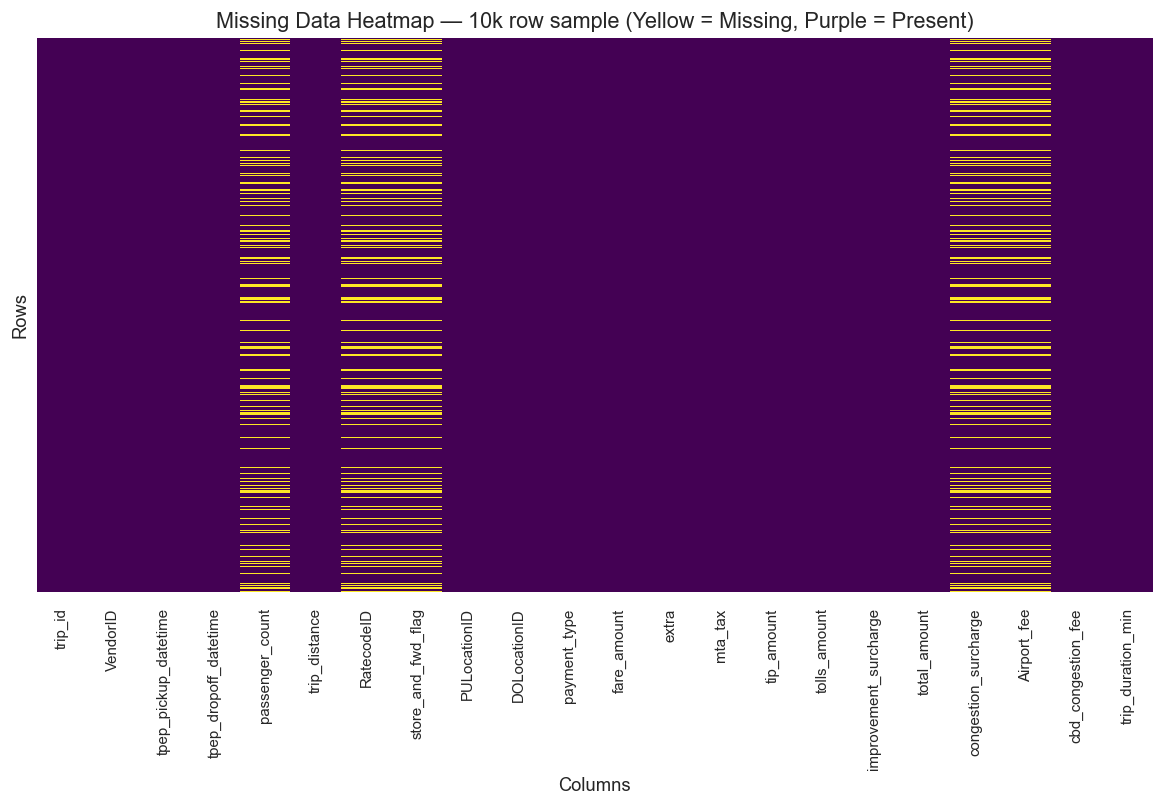

In [59]:
if 'df' in locals():
    sample = df.sample(n=10_000, random_state=42) if len(df) > 10_000 else df

    plt.figure(figsize=(12, 6))
    sns.heatmap(sample.isnull(), cbar=False, yticklabels=False, cmap='viridis')
    plt.title("Missing Data Heatmap — 10k row sample (Yellow = Missing, Purple = Present)")
    plt.xlabel("Columns")
    plt.ylabel("Rows")
    plt.show()
